# 🔩 End-to-End Multi-Class Classification Pipeline — Gelişmiş Sürüm
## Steel Plates Faults Dataset (UCI)

**Amaç:** Çelik plaka yüzey hatası sınıflandırması için uçtan uca, yeniden çalıştırılabilir bir ML pipeline'ı.


---
**Pipeline Akışı:**  
`EDA` → `Ön İşleme` → `SMOTE Karşılaştırması` → `Özellik Seçimi (3 Yöntem)` → `Model: Tüm / Seçilen / PCA` → `Final Karşılaştırma`


## 📦 Step 0 — Kurulum ve İmportlar

In [2]:
import subprocess, sys
pkgs = [
    'ucimlrepo', 'xgboost', 'lightgbm', 'imbalanced-learn',
    'shap', 'umap-learn', 'scikit-learn', 'matplotlib',
    'seaborn', 'pandas', 'numpy', 'scipy'
]
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)
print('✅ Tüm paketler kuruldu.')

✅ Tüm paketler kuruldu.


In [3]:
import warnings, random
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# Veri / ön işleme
from ucimlrepo import fetch_ucirepo
from sklearn.impute import KNNImputer
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import (LabelEncoder, StandardScaler,
                                   MinMaxScaler, label_binarize)
from sklearn.model_selection import (train_test_split, RandomizedSearchCV,
                                     StratifiedKFold, cross_val_score)

# Özellik seçimi
from sklearn.feature_selection import SelectKBest, f_classif, RFE

# Boyut düşürme
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# Dengesizlik
from imblearn.over_sampling import SMOTE

# Modeller
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb

# Değerlendirme
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, auc, average_precision_score
)

# SHAP
import shap

# Tekrarlanabilirlik
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Global görsel stil
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.0)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 6)})

print('✅ Tüm importlar başarılı.')

✅ Tüm importlar başarılı.


## 📊 Step 1 — Keşifsel Veri Analizi (EDA) ve Veri Hazırlığı

### 1.1 Veri Yükleme

In [4]:
# UCI ID=198 — Steel Plates Faults
dataset = fetch_ucirepo(id=198)
X_raw = dataset.data.features.copy()
y_raw = dataset.data.targets.copy()

print('Özellik matrisi boyutu :', X_raw.shape)
print('Hedef matrisi boyutu   :', y_raw.shape)
print('\nÖzellik sütunları:', X_raw.columns.tolist())
print('Hedef sütunları  :', y_raw.columns.tolist())

Özellik matrisi boyutu : (1941, 27)
Hedef matrisi boyutu   : (1941, 7)

Özellik sütunları: ['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer', 'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness', 'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index', 'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index', 'SigmoidOfAreas', 'Minimum_of_Luminosity']
Hedef sütunları  : ['Pastry', 'Z_Scratch', 'K_Scratch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']


In [5]:
# One-hot hedefi → tek tamsayı etiketi
fault_names = y_raw.columns.tolist()
y           = y_raw.idxmax(axis=1)
le          = LabelEncoder()
y_enc       = le.fit_transform(y)
class_names = le.classes_
n_classes   = len(class_names)

print(f'Sınıflar ({n_classes}):', class_names)
print('Örnek kodlama:', dict(zip(class_names, le.transform(class_names))))
X = X_raw.copy()
X.head(10)

Sınıflar (7): ['Bumps' 'Dirtiness' 'K_Scratch' 'Other_Faults' 'Pastry' 'Stains'
 'Z_Scratch']
Örnek kodlama: {'Bumps': 0, 'Dirtiness': 1, 'K_Scratch': 2, 'Other_Faults': 3, 'Pastry': 4, 'Stains': 5, 'Z_Scratch': 6}


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,...,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Minimum_of_Luminosity
0,42,50,270900,270944,267,17,44,24220,108,1687,...,0.4706,1.0000,1.0,2.4265,0.9031,1.6435,0.8182,-0.2913,0.5822,76
1,645,651,2538079,2538108,108,10,30,11397,123,1687,...,0.6000,0.9667,1.0,2.0334,0.7782,1.4624,0.7931,-0.1756,0.2984,84
2,829,835,1553913,1553931,71,8,19,7972,125,1623,...,0.7500,0.9474,1.0,1.8513,0.7782,1.2553,0.6667,-0.1228,0.2150,99
3,853,860,369370,369415,176,13,45,18996,126,1353,...,0.5385,1.0000,1.0,2.2455,0.8451,1.6532,0.8444,-0.1568,0.5212,99
4,1289,1306,498078,498335,2409,60,260,246930,126,1353,...,0.2833,0.9885,1.0,3.3818,1.2305,2.4099,0.9338,-0.1992,1.0000,37
5,430,441,100250,100337,630,20,87,62357,127,1387,...,0.5500,1.0000,1.0,2.7993,1.0414,1.9395,0.8736,-0.2267,0.9874,64
6,413,446,138468,138883,9052,230,432,1481991,199,1687,...,0.1435,0.9607,1.0,3.9567,1.5185,2.6181,0.9205,0.2791,1.0000,23
7,190,200,210936,210956,132,11,20,20007,172,1687,...,0.9091,1.0000,1.0,2.1206,1.0000,1.3010,0.5000,0.1841,0.3359,124
8,330,343,429227,429253,264,15,26,29748,148,1687,...,0.8667,1.0000,1.0,2.4216,1.1139,1.4150,0.5000,-0.1197,0.5593,53
9,74,90,779144,779308,1506,46,167,180215,143,1687,...,0.3478,0.9820,1.0,3.1778,1.2041,2.2148,0.9024,-0.0651,1.0000,53


In [6]:
y_raw.head(10)

,Pastry,Z_Scratch,K_Scratch,Stains,Dirtiness,Bumps,Other_Faults
0,1,0,0,0,0,0,0
1,1,0,0,0,0,0,0
2,1,0,0,0,0,0,0
3,1,0,0,0,0,0,0
4,1,0,0,0,0,0,0
5,1,0,0,0,0,0,0
6,1,0,0,0,0,0,0
7,1,0,0,0,0,0,0
8,1,0,0,0,0,0,0
9,1,0,0,0,0,0,0


In [7]:
y_enc

array([4, 4, 4, ..., 3, 3, 3])

### 1.2 Kategorik / Sayısal Özellik Ayrımı

In [8]:
cat_cols = [c for c in X.columns if X[c].nunique() <= 2
            and X[c].dtype in [np.int64, np.float64]]
num_cols = [c for c in X.columns if c not in cat_cols]

print(f'Kategorik özellikler ({len(cat_cols)}): {cat_cols}')
print(f'Sayısal özellikler   ({len(num_cols)}): {num_cols}')

Kategorik özellikler (2): ['TypeOfSteel_A300', 'TypeOfSteel_A400']
Sayısal özellikler   (25): ['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer', 'Steel_Plate_Thickness', 'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index', 'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index', 'SigmoidOfAreas', 'Minimum_of_Luminosity']


### 1.3 Eksik Değer Analizi ve KNN İmputer

In [9]:
missing = X.isnull().sum()
print('Eksik değer kontrolü:')
print(missing[missing > 0] if missing.sum() > 0 else 'Eksik değer yok.')

# Savunmacı imputation — gelecekte gelebilecek eksikliklere karşı
imputer   = KNNImputer(n_neighbors=5)
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
X         = X_imputed.copy()
print('\nKNNImputer tamamlandı. Kalan NaN:', X.isnull().sum().sum())

Eksik değer kontrolü:
Eksik değer yok.

KNNImputer tamamlandı. Kalan NaN: 0


### 1.4 Sayısal Özellik Dağılımları

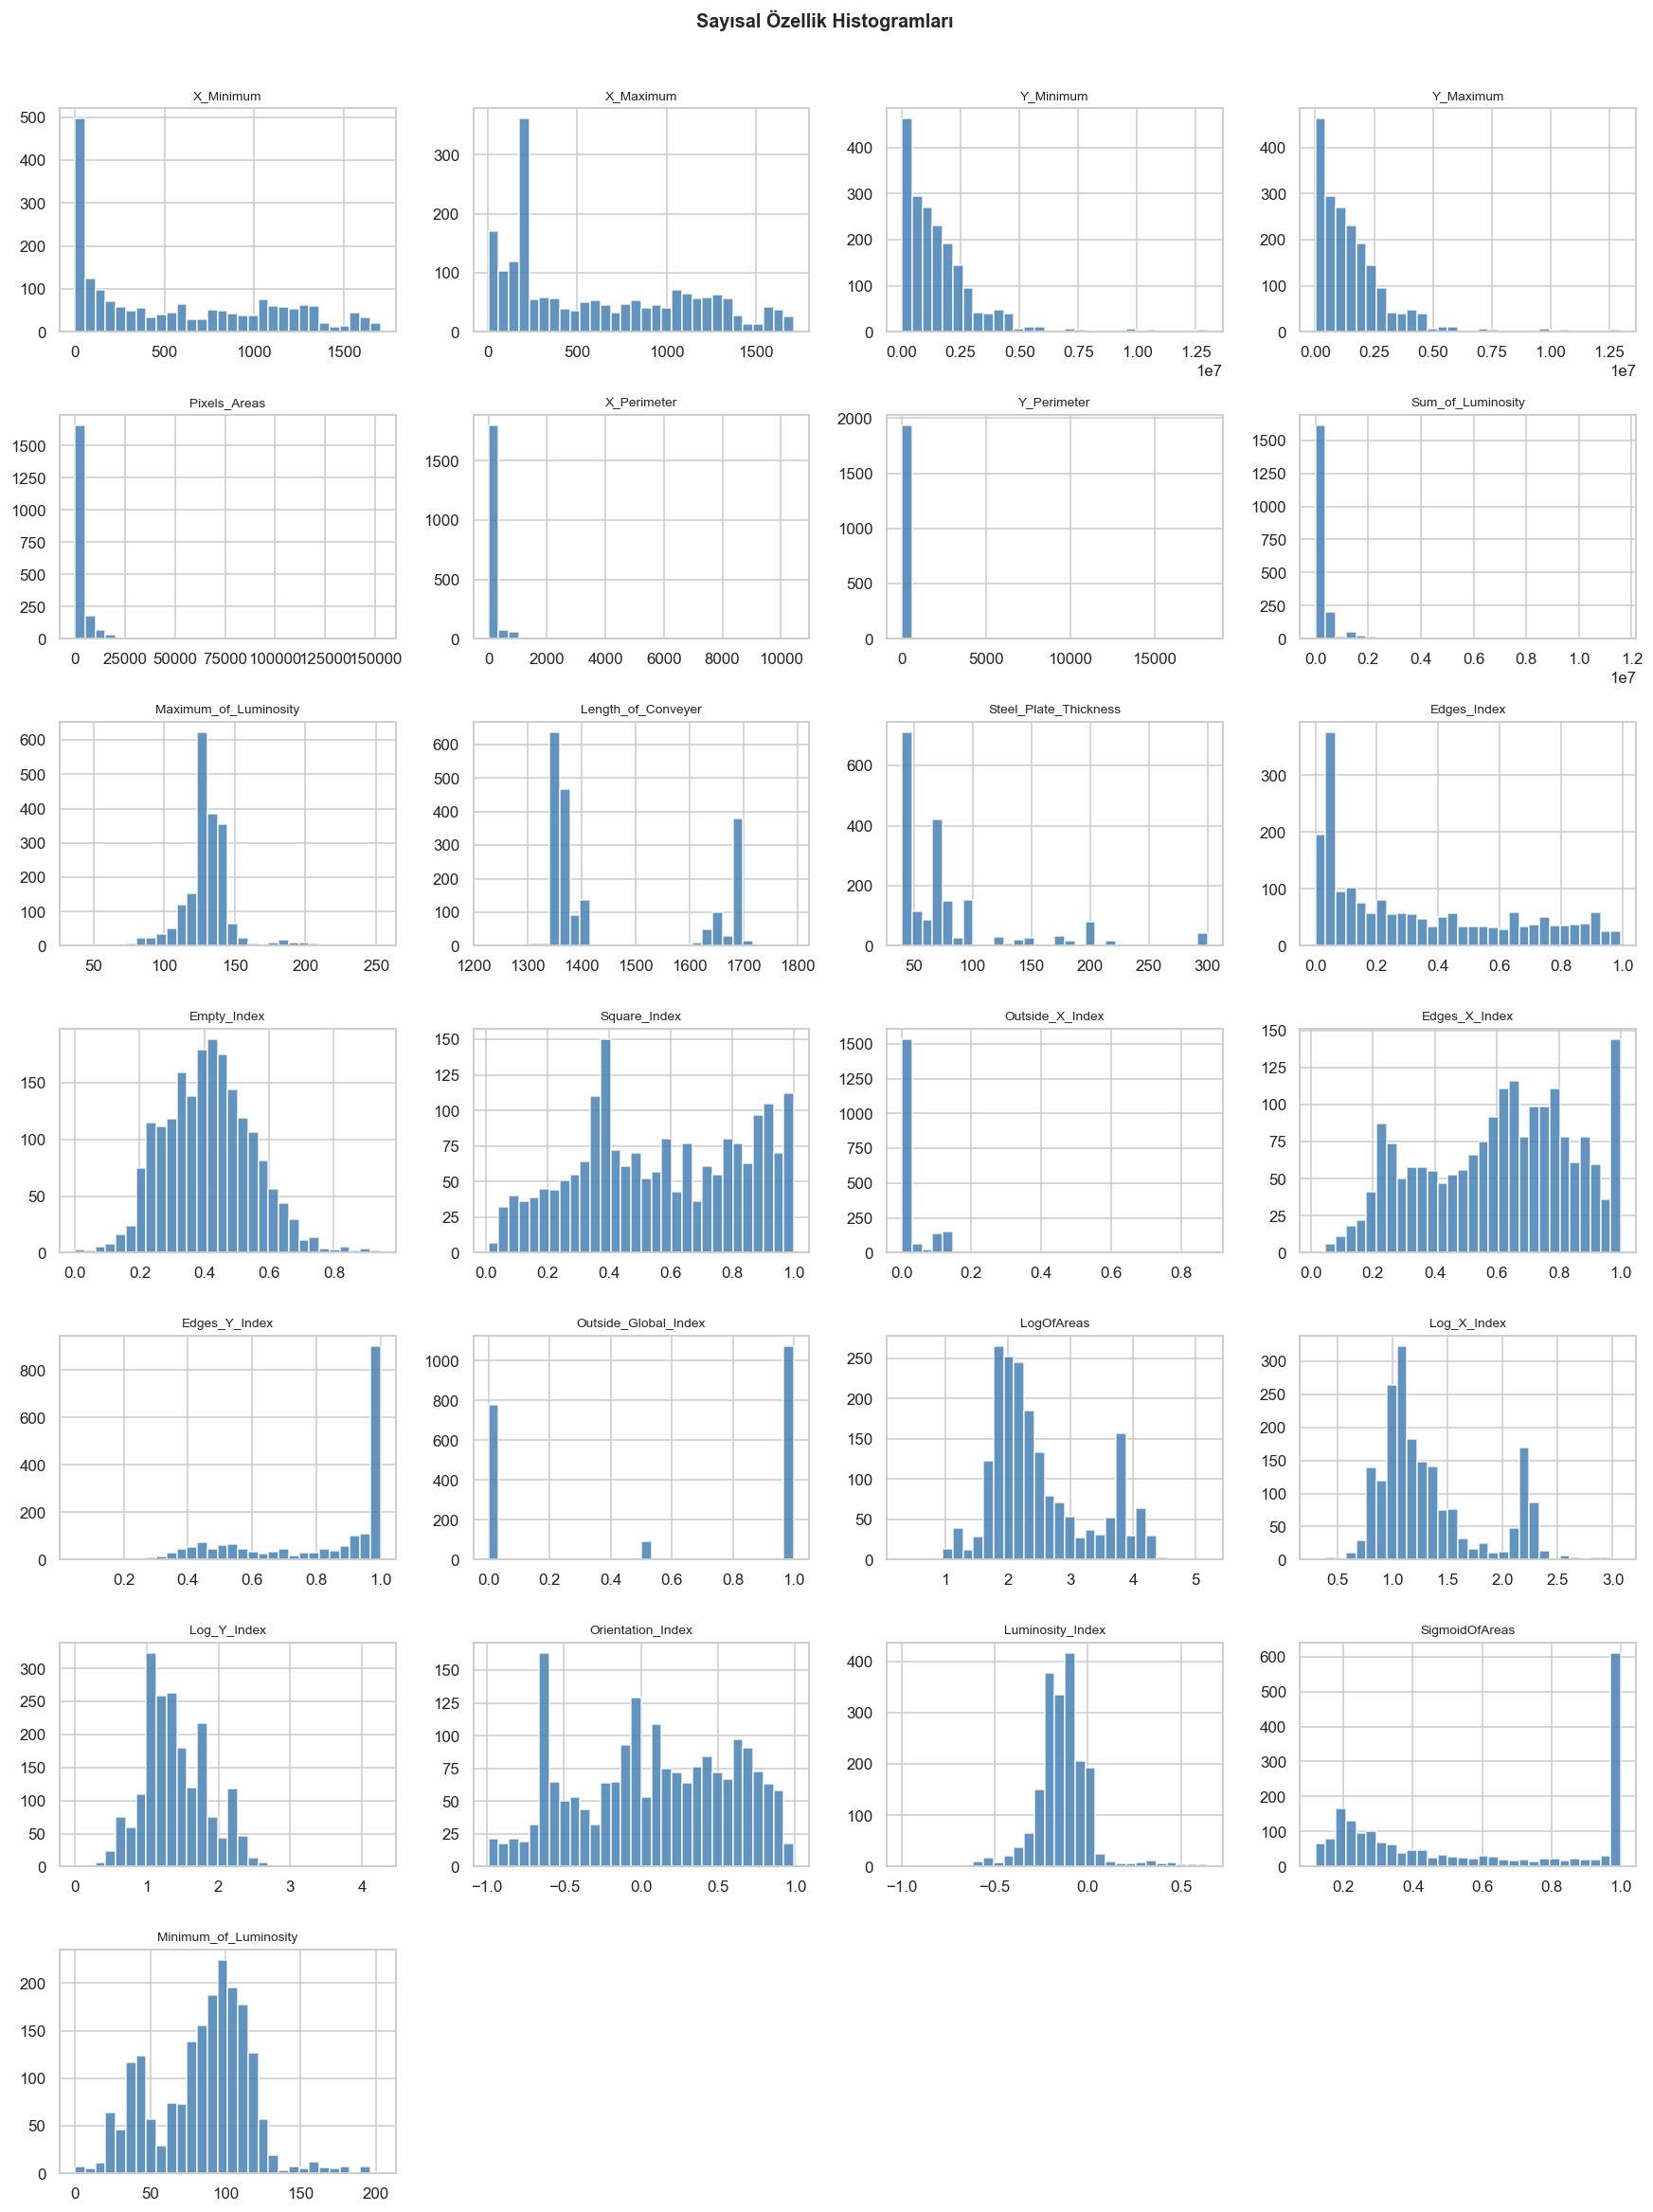

In [10]:
n_num = len(num_cols)
ncols_hist = 4
nrows_hist = (n_num + ncols_hist - 1) // ncols_hist
fig, axes  = plt.subplots(nrows_hist, ncols_hist,
                           figsize=(ncols_hist * 4, nrows_hist * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(X[col].dropna(), bins=30, color='steelblue',
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Sayısal Özellik Histogramları', y=1.01,
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.5 Aykırı Değer Tespiti — LOF

LOF: 97 aykırı değer (5.0%)


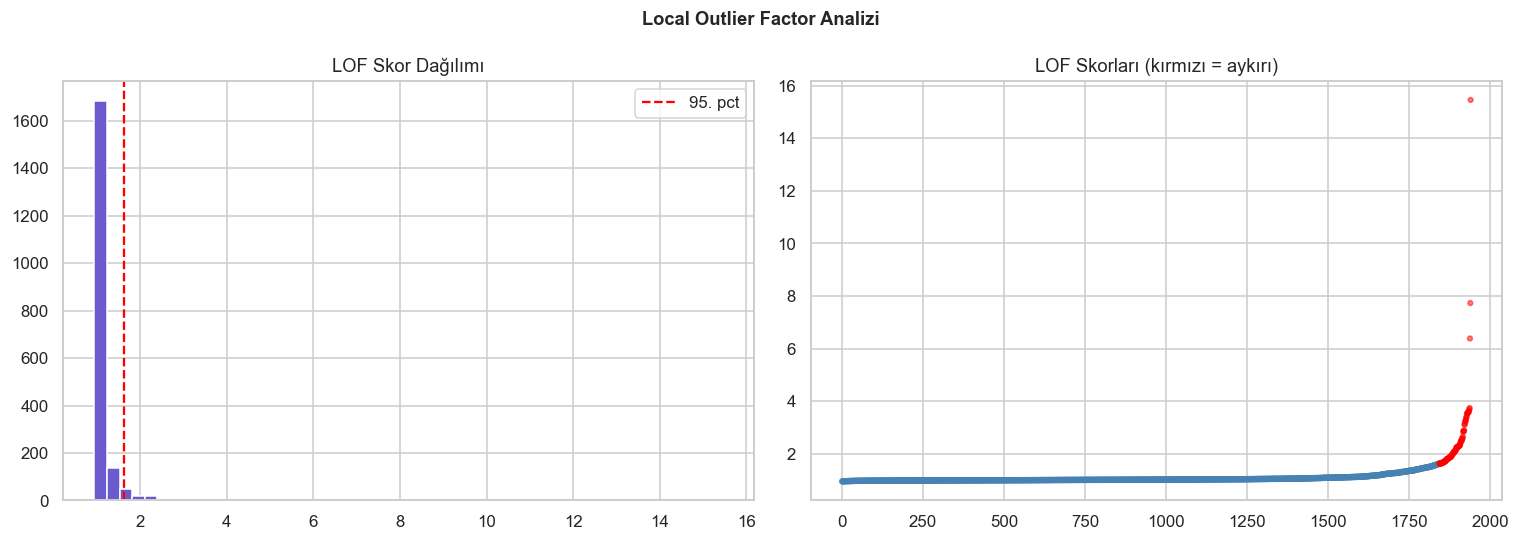

📌 Aykırı değerler çıkarılmadı; nadir hata alt-tipleri içerebilir.


In [11]:
lof        = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels = lof.fit_predict(X)
lof_scores = -lof.negative_outlier_factor_

n_out = (lof_labels == -1).sum()
print(f'LOF: {n_out} aykırı değer ({n_out/len(X)*100:.1f}%)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.hist(lof_scores, bins=50, color='slateblue', edgecolor='white')
ax1.axvline(np.percentile(lof_scores, 95), color='red',
            linestyle='--', label='95. pct')
ax1.set_title('LOF Skor Dağılımı'); ax1.legend()

colors_lof = np.where(lof_labels == -1, 'red', 'steelblue')
ax2.scatter(range(len(lof_scores)), np.sort(lof_scores),
            c=colors_lof[np.argsort(lof_scores)], alpha=0.5, s=10)
ax2.set_title('LOF Skorları (kırmızı = aykırı)')

plt.suptitle('Local Outlier Factor Analizi', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# Aykırı değerler tutulur — geçerli nadir hata türleri olabilir
print('📌 Aykırı değerler çıkarılmadı; nadir hata alt-tipleri içerebilir.')

Toplam 97 aykırı değerin sınıflara göre dağılımı:

Target
Other_Faults    38
K_Scratch       24
Z_Scratch       13
Pastry          13
Bumps            7
Dirtiness        2
Name: count, dtype: int64
--------------------------------------------------


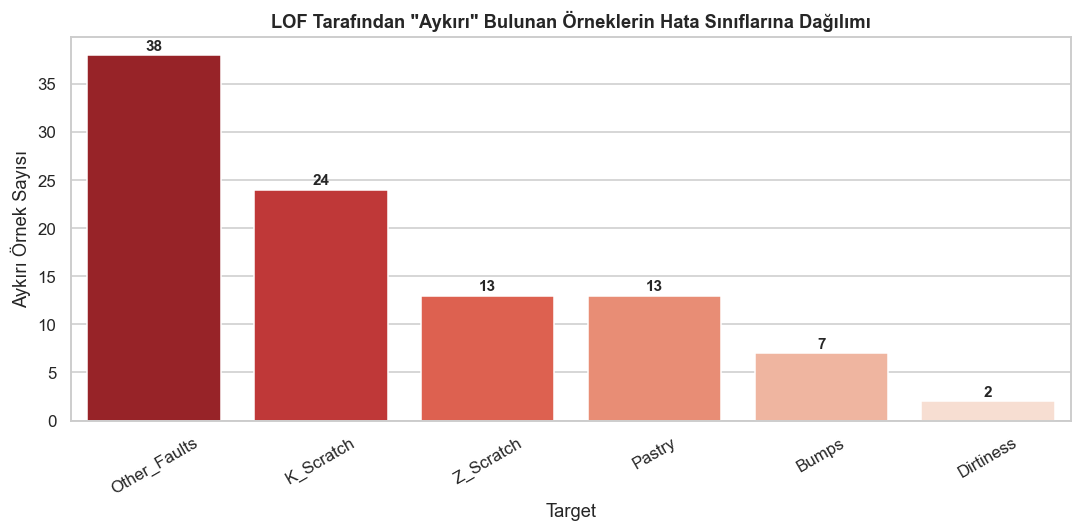


🚨 En yüksek LOF skoruna sahip ilk 5 aykırı örneğin detaylı görünümü:


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,...,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Minimum_of_Luminosity
391,19.0,169.0,4197607.0,4215748.0,152655.0,10449.0,18152.0,11591414.0,156.0,1336.0,...,0.0144,0.9994,1.0,5.1837,2.1761,4.2587,0.9917,-0.4068,1.0,0.0
1592,15.0,149.0,2278497.0,2278909.0,37334.0,908.0,903.0,3918209.0,134.0,1387.0,...,0.1476,0.4563,1.0,4.5721,2.1271,2.6149,0.6748,-0.1801,1.0,19.0
346,1190.0,1219.0,1183612.0,1183893.0,3883.0,229.0,289.0,395668.0,127.0,1362.0,...,0.1266,0.9723,1.0,3.5892,1.4624,2.4487,0.8968,-0.2039,1.0,78.0
79,1321.0,1339.0,513812.0,514011.0,2145.0,134.0,201.0,228995.0,133.0,1380.0,...,0.1343,0.9901,1.0,3.3314,1.2553,2.2989,0.9096,-0.1660,1.0,16.0
1565,526.0,676.0,1470973.0,1471038.0,1939.0,192.0,116.0,239860.0,247.0,1692.0,...,0.7813,0.5603,0.0,3.2876,2.1761,1.8129,-0.5667,-0.0336,1.0,109.0


In [12]:
# 1. Aykırı değerleri filtreleme (lof_labels == -1 olanlar)
outlier_mask = (lof_labels == -1)
df_outliers = X[outlier_mask].copy()

# Orijinal string etiketleri ve LOF skorlarını veri setine ekleyelim
df_outliers['Target'] = y[outlier_mask].values
df_outliers['LOF_Score'] = lof_scores[outlier_mask]

# Skora göre büyükten küçüğe sıralayalım (en aykırılar en üstte)
df_outliers = df_outliers.sort_values(by='LOF_Score', ascending=False)

# ==========================================
# 2. Aykırı Değerlerin Hedef Sınıflara Dağılımı
# ==========================================
outlier_counts = df_outliers['Target'].value_counts()
print(f"Toplam {n_out} aykırı değerin sınıflara göre dağılımı:\n")
print(outlier_counts)
print("-" * 50)

# Görselleştirme
plt.figure(figsize=(10, 5))
sns.barplot(x=outlier_counts.index, y=outlier_counts.values, palette='Reds_r')
plt.title('LOF Tarafından "Aykırı" Bulunan Örneklerin Hata Sınıflarına Dağılımı', fontsize=12, fontweight='bold')
plt.ylabel('Aykırı Örnek Sayısı')
plt.xticks(rotation=30)

# Çubukların üzerine sayıları yazdırma
for i, count in enumerate(outlier_counts.values):
    plt.text(i, count + 0.5, str(count), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# 3. En Uç (Extreme) İlk 5 Aykırı Değerin İncelenmesi
# ==========================================
print("\n🚨 En yüksek LOF skoruna sahip ilk 5 aykırı örneğin detaylı görünümü:")
# Sadece özelliklerin öne çıkanlarını ve target'ı göstermek için
cols_to_show = X_raw.columns
display(df_outliers[cols_to_show].head())

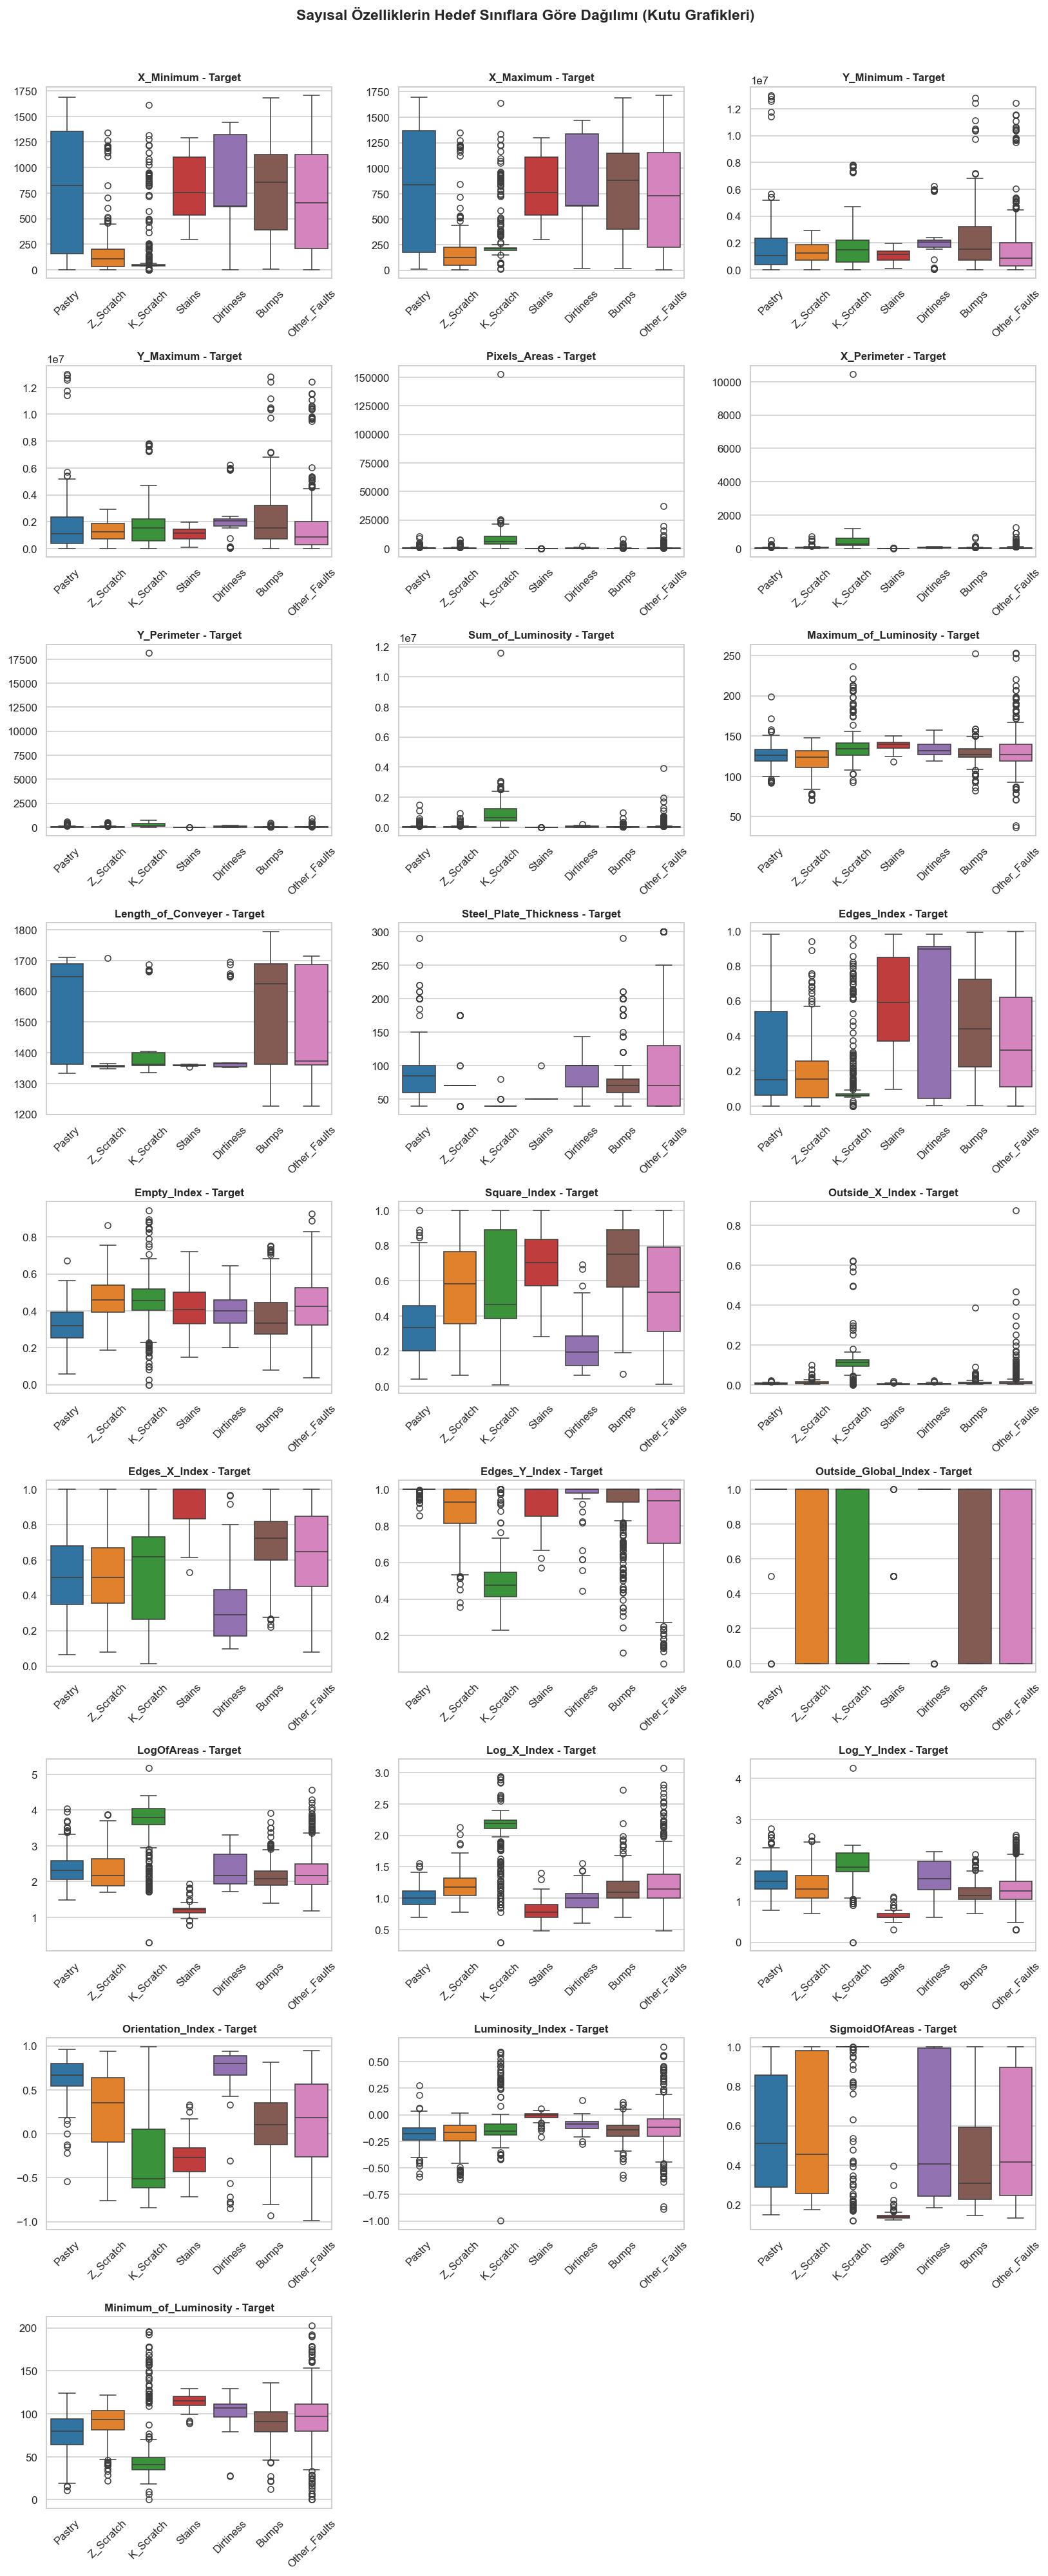

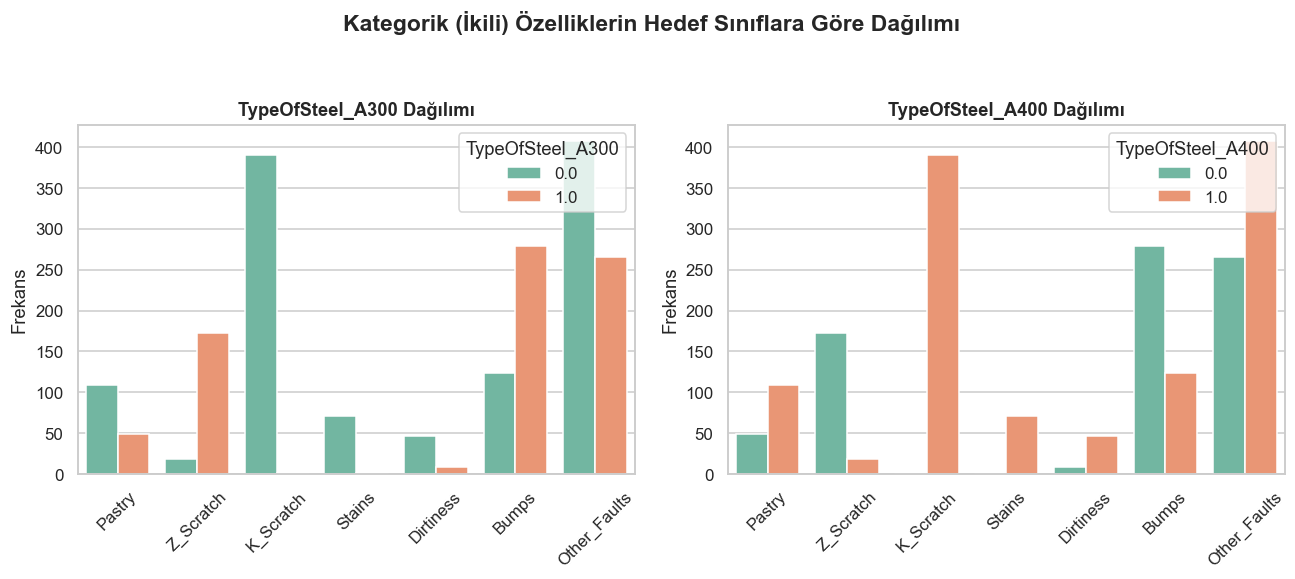

In [13]:
# Analiz için veriyi okunabilir hedef değişkeniyle birleştirelim
df_eda = X.copy()
df_eda['Target'] = y # Sayısal y_enc yerine string etiketleri (Bumps, Pastry vb.) kullanıyoruz

# ==========================================
# 1. SAYISAL ÖZELLİKLER İÇİN BOXPLOT
# ==========================================
n_num = len(num_cols)
ncols_box = 3
nrows_box = (n_num + ncols_box - 1) // ncols_box

fig_box, axes_box = plt.subplots(nrows_box, ncols_box, figsize=(ncols_box * 5, nrows_box * 4))
axes_box = axes_box.flatten()

for i, col in enumerate(num_cols):
    # Sınıfları renklendirerek her özelliğin hata tipine göre dağılımını çizdiriyoruz
    sns.boxplot(x='Target', y=col, data=df_eda, ax=axes_box[i], palette='tab10')
    axes_box[i].set_title(f'{col} - Target', fontsize=11, fontweight='bold')
    axes_box[i].tick_params(axis='x', rotation=45)
    axes_box[i].set_xlabel('')
    axes_box[i].set_ylabel('')

# Kullanılmayan boş alt grafikleri (axes) gizleme
for j in range(i + 1, len(axes_box)):
    axes_box[j].set_visible(False)

plt.suptitle('Sayısal Özelliklerin Hedef Sınıflara Göre Dağılımı (Kutu Grafikleri)',
             y=1.01, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# 2. KATEGORİK ÖZELLİKLER İÇİN COUNTPLOT
# ==========================================
n_cat = len(cat_cols)
fig_cat, axes_cat = plt.subplots(1, max(n_cat, 2), figsize=(12, 5))
# Eğer tek kategorik değişken varsa axes'in array olmasını garantiye alıyoruz

if n_cat == 1:
    axes_cat = [axes_cat[0]]

for i, col in enumerate(cat_cols):
    # İkili (Binary) çelik tipi değişkenlerinin hangi hatalarda daha sık görüldüğünü inceliyoruz
    sns.countplot(data=df_eda, x='Target', hue=col, ax=axes_cat[i], palette='Set2')
    axes_cat[i].set_title(f'{col} Dağılımı', fontsize=12, fontweight='bold')
    axes_cat[i].tick_params(axis='x', rotation=45)
    axes_cat[i].set_xlabel('')
    axes_cat[i].set_ylabel('Frekans')
    axes_cat[i].legend(title=col, loc='upper right')

# Kullanılmayan boş kategorik alt grafikleri gizleme
for j in range(i + 1, len(axes_cat)):
    axes_cat[j].set_visible(False)

plt.suptitle('Kategorik (İkili) Özelliklerin Hedef Sınıflara Göre Dağılımı',
             y=1.05, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.6 Sınıf Dağılımı

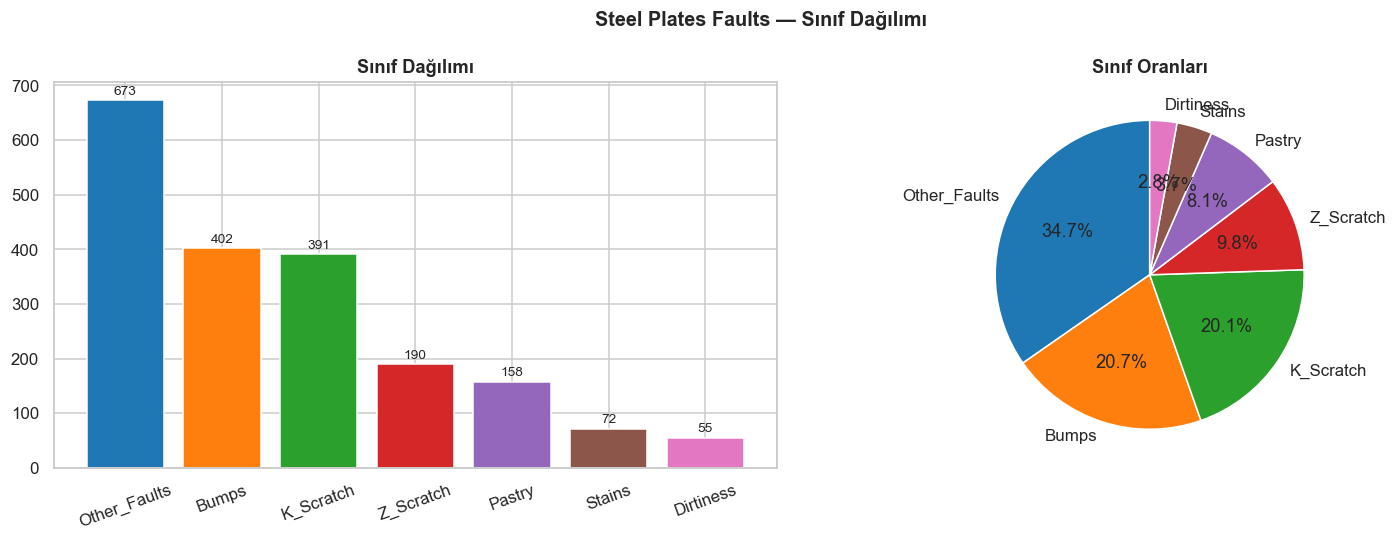


Sınıf sayıları:
Other_Faults    673
Bumps           402
K_Scratch       391
Z_Scratch       190
Pastry          158
Stains           72
Dirtiness        55
Name: count, dtype: int64

Dengesizlik oranı: 12.24x
→ SMOTE yalnızca eğitim setine uygulanacak.


In [14]:
class_counts   = pd.Series(y_enc).map(dict(enumerate(class_names))).value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()
palette        = sns.color_palette('tab10', n_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Çubuk grafik
bars = axes[0].bar(class_counts.index, class_counts.values, color=palette)
for bar, cnt in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5, str(cnt),
                 ha='center', va='bottom', fontsize=9)
axes[0].set_title('Sınıf Dağılımı', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

# Pasta grafik
axes[1].pie(class_counts.values, labels=class_counts.index,
            colors=palette, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Sınıf Oranları', fontweight='bold')

plt.suptitle('Steel Plates Faults — Sınıf Dağılımı', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'\nSınıf sayıları:\n{class_counts}')
print(f'\nDengesizlik oranı: {imbalance_ratio:.2f}x')
print('→ SMOTE yalnızca eğitim setine uygulanacak.')

### 1.7 Korelasyon Isı Haritası

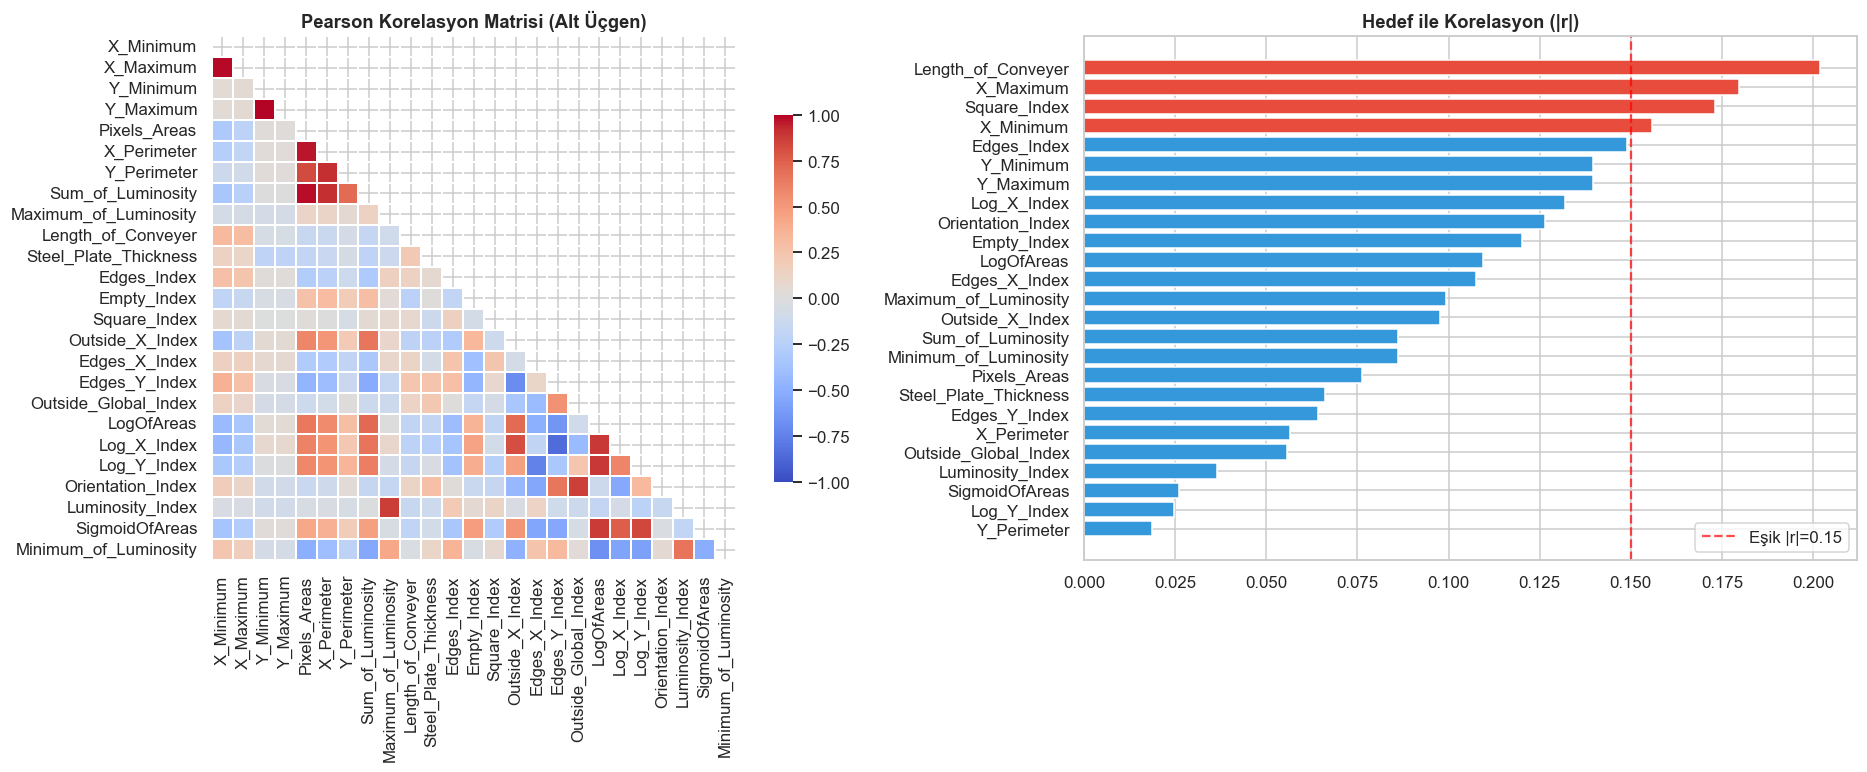

📌 Koyu kırmızı/mavi hücreler güçlü korelasyonu gösterir — özellik seçimini motive eder.


In [15]:
corr_matrix = X[num_cols].corr(method='pearson')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, linewidths=0.3, annot=False,
            square=True, ax=axes[0], cbar_kws={'shrink': 0.7})
axes[0].set_title('Pearson Korelasyon Matrisi (Alt Üçgen)',
                  fontweight='bold')

# Hedef ile korelasyon
y_series      = pd.Series(y_enc, name='Hedef')
target_corr   = X[num_cols].corrwith(y_series).abs().sort_values()
colors_bar    = ['#e74c3c' if v > 0.15 else '#3498db'
                 for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values,
             color=colors_bar, edgecolor='white')
axes[1].axvline(0.15, color='red', linestyle='--', alpha=0.7,
                label='Eşik |r|=0.15')
axes[1].set_title('Hedef ile Korelasyon (|r|)', fontweight='bold')
axes[1].legend()

plt.tight_layout(); plt.show()
print('📌 Koyu kırmızı/mavi hücreler güçlü korelasyonu gösterir — özellik seçimini motive eder.')

### 1.8 Betimleyici İstatistikler

In [16]:
desc            = X[num_cols].describe().T
desc['çarpıklık'] = X[num_cols].skew()
desc['basıklık']  = X[num_cols].kurtosis()
print('Betimleyici İstatistikler:')
desc.round(3)

Betimleyici İstatistikler:


,count,mean,std,min,25%,50%,75%,max,çarpıklık,basıklık
X_Minimum,1941.0,571.136,520.691,0.000,51.000,435.000,1053.000,1.705000e+03,0.501,-1.145
X_Maximum,1941.0,617.964,497.627,4.000,192.000,467.000,1072.000,1.713000e+03,0.524,-1.078
Y_Minimum,1941.0,1650684.868,1774578.415,6712.000,471253.000,1204128.000,2183073.000,1.298766e+07,2.811,11.358
Y_Maximum,1941.0,1650738.705,1774590.089,6724.000,471281.000,1204136.000,2183084.000,1.298769e+07,2.811,11.357
Pixels_Areas,1941.0,1893.878,5168.460,2.000,84.000,174.000,822.000,1.526550e+05,14.084,375.838
X_Perimeter,1941.0,111.855,301.209,2.000,15.000,26.000,84.000,1.044900e+04,21.539,715.957
Y_Perimeter,1941.0,82.966,426.483,1.000,13.000,25.000,83.000,1.815200e+04,39.293,1663.052
Sum_of_Luminosity,1941.0,206312.148,512293.588,250.000,9522.000,19202.000,83011.000,1.159141e+07,7.731,131.495
Maximum_of_Luminosity,1941.0,130.194,18.691,37.000,124.000,127.000,140.000,2.530000e+02,1.287,7.858
Length_of_Conveyer,1941.0,1459.160,144.578,1227.000,1358.000,1364.000,1650.000,1.794000e+03,0.851,-1.192


## 🔍 Step 2 — Özellik Seçimi: Üç Yöntem Karşılaştırması

**Üç yöntem paralel çalıştırılır ve sonuçlar tek bir karşılaştırma tablosunda özetlenir:**

| Yöntem | Tip | Açıklama |
|--------|-----|----------|
| **ANOVA F-testi (SelectKBest)** | Filtre | Sınıflar arası varyans / sınıf içi varyans oranı |
| **RF Özellik Önemi** | Gömülü | Orman genelinde Gini safsızlığı azalması |
| **RFE (Recursive Feature Elimination)** | Sarıcı | Geriye elimine ederek optimal küme bulma |


### 2.1 Pearson + Cosine Filtresi (Ön Eleme)

In [17]:
# ── Pearson Filtresi |r| > 0.90 ──────────────────────────────────────
pearson_threshold = 0.90
corr_abs          = corr_matrix.abs()
cols_list         = corr_abs.columns.tolist()

high_pearson = []
for i in range(len(cols_list)):
    for j in range(i + 1, len(cols_list)):
        r = corr_abs.iloc[i, j]
        if r > pearson_threshold:
            high_pearson.append({'Özellik A': cols_list[i],
                                  'Özellik B': cols_list[j],
                                  '|r|': round(r, 4)})

pearson_df = pd.DataFrame(high_pearson).sort_values('|r|', ascending=False)
print(f'Pearson |r| > {pearson_threshold} çiftleri:')
print(pearson_df.to_string(index=False) if not pearson_df.empty else 'Yok')

# ── Cosine Filtresi > 0.95 ────────────────────────────────────────────
cosine_threshold = 0.95
feat_matrix  = X[num_cols].values.T
norms        = np.linalg.norm(feat_matrix, axis=1, keepdims=True)
norms[norms == 0] = 1e-10
feat_norm    = feat_matrix / norms
cos_sim      = feat_norm @ feat_norm.T

high_cosine = []
for i in range(len(num_cols)):
    for j in range(i + 1, len(num_cols)):
        cs = abs(cos_sim[i, j])
        if cs > cosine_threshold:
            high_cosine.append({'Özellik A': num_cols[i],
                                 'Özellik B': num_cols[j],
                                 'Cosine': round(cs, 4)})

cosine_df = pd.DataFrame(high_cosine).sort_values('Cosine', ascending=False)
print(f'\nCosine > {cosine_threshold} çiftleri:')
print(cosine_df.to_string(index=False) if not cosine_df.empty else 'Yok')

# ── Düşürülecekler ────────────────────────────────────────────────────
to_drop = (set(pearson_df['Özellik B'].tolist() if not pearson_df.empty else [])
           | set(cosine_df['Özellik B'].tolist() if not cosine_df.empty else []))

X_filtered = X.drop(columns=[c for c in to_drop if c in X.columns])
print(f'\nPearson+Cosine filtresi sonrası özellik sayısı: {X_filtered.shape[1]}')

Pearson |r| > 0.9 çiftleri:
   Özellik A         Özellik B    |r|
   Y_Minimum         Y_Maximum 1.0000
   X_Minimum         X_Maximum 0.9883
Pixels_Areas Sum_of_Luminosity 0.9790
Pixels_Areas       X_Perimeter 0.9666
 X_Perimeter Sum_of_Luminosity 0.9130
 X_Perimeter       Y_Perimeter 0.9124

Cosine > 0.95 çiftleri:
            Özellik A          Özellik B  Cosine
            Y_Minimum          Y_Maximum  1.0000
            X_Minimum          X_Maximum  0.9932
           LogOfAreas        Log_Y_Index  0.9891
           LogOfAreas        Log_X_Index  0.9879
Maximum_of_Luminosity Length_of_Conveyer  0.9837
         Pixels_Areas  Sum_of_Luminosity  0.9812
         Pixels_Areas        X_Perimeter  0.9706
   Length_of_Conveyer      Edges_Y_Index  0.9627
           LogOfAreas     SigmoidOfAreas  0.9576
          Log_X_Index        Log_Y_Index  0.9575
          Log_Y_Index     SigmoidOfAreas  0.9526

Pearson+Cosine filtresi sonrası özellik sayısı: 17


### 2.2 Yöntem 1 — ANOVA F-testi (SelectKBest)

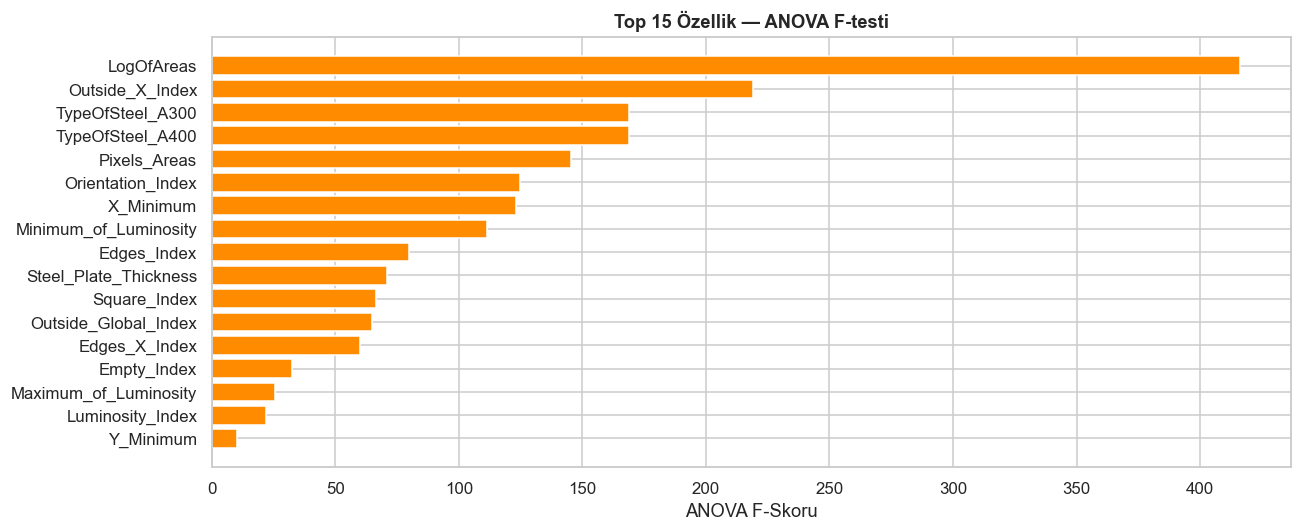


ANOVA seçilen özellikler (15): ['LogOfAreas', 'Outside_X_Index', 'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Pixels_Areas', 'Orientation_Index', 'X_Minimum', 'Minimum_of_Luminosity', 'Edges_Index', 'Steel_Plate_Thickness', 'Square_Index', 'Outside_Global_Index', 'Edges_X_Index', 'Empty_Index', 'Maximum_of_Luminosity']


In [18]:
k_anova = min(15, X_filtered.shape[1])
selector_anova = SelectKBest(f_classif, k=k_anova)
selector_anova.fit(X_filtered, y_enc)

anova_df = pd.DataFrame({
    'Özellik'   : X_filtered.columns,
    'F-Skoru'   : selector_anova.scores_.round(2),
    'p-değeri'  : selector_anova.pvalues_.round(4),
    'ANOVA Seç' : selector_anova.get_support()
}).sort_values('F-Skoru', ascending=False).reset_index(drop=True)

selected_anova = anova_df[anova_df['ANOVA Seç']]['Özellik'].tolist()

fig, ax = plt.subplots(figsize=(12, 5))
top_anova = anova_df.head(20)
ax.barh(top_anova['Özellik'][::-1], top_anova['F-Skoru'][::-1],
        color='darkorange', edgecolor='white')
ax.set_xlabel('ANOVA F-Skoru')
ax.set_title(f'Top {k_anova} Özellik — ANOVA F-testi', fontweight='bold')
plt.tight_layout(); plt.show()

print(f'\nANOVA seçilen özellikler ({len(selected_anova)}): {selected_anova}')

# ANOVA seçili veriyi bir sonraki adımlar için sakla
X_anova = X_filtered[selected_anova]

### 2.3 Yöntem 2 — Random Forest Özellik Önemi

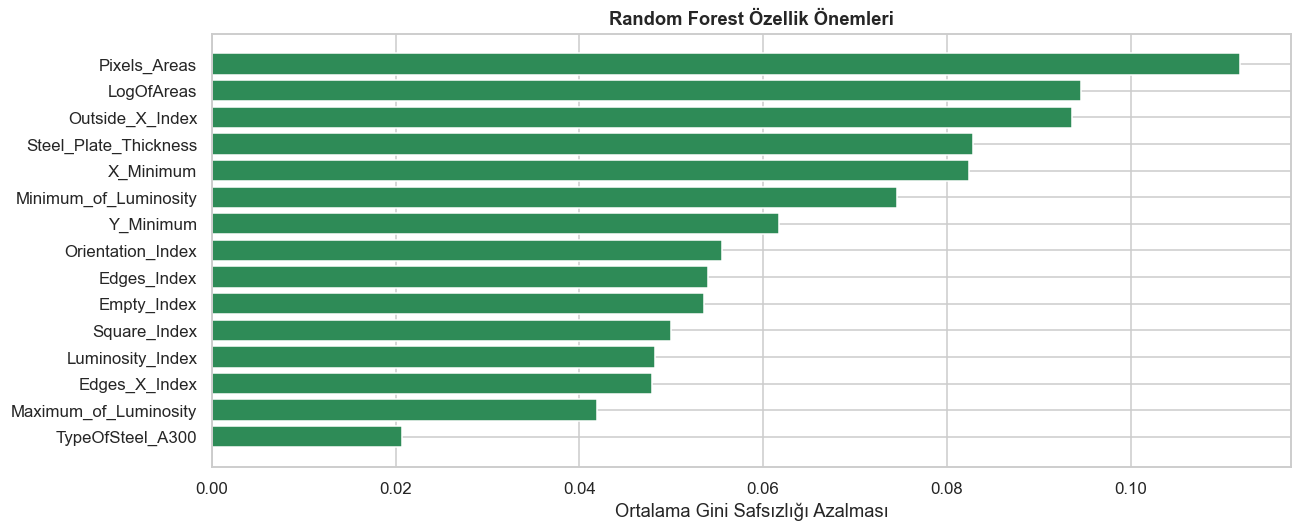

RF seçilen özellikler (15): ['Pixels_Areas', 'LogOfAreas', 'Outside_X_Index', 'Steel_Plate_Thickness', 'X_Minimum', 'Minimum_of_Luminosity', 'Y_Minimum', 'Orientation_Index', 'Edges_Index', 'Empty_Index', 'Square_Index', 'Luminosity_Index', 'Edges_X_Index', 'Maximum_of_Luminosity', 'TypeOfSteel_A300']


In [19]:
rf_imp = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_imp.fit(X_filtered, y_enc)
rf_imp_df = pd.DataFrame({
    'Özellik'  : X_filtered.columns,
    'RF Önemi' : rf_imp.feature_importances_.round(4)
}).sort_values('RF Önemi', ascending=False).reset_index(drop=True)

k_rf        = min(15, len(rf_imp_df))
selected_rf = rf_imp_df.head(k_rf)['Özellik'].tolist()

# RF top-k (ANOVA'daki k ile aynı sayıda alıyoruz)
k_rf          = min(k_anova, len(rf_imp_df))
selected_rf   = rf_imp_df.head(k_rf)['Özellik'].tolist()

fig, ax = plt.subplots(figsize=(12, 5))
top_rf = rf_imp_df.head(k_rf)
ax.barh(top_rf['Özellik'][::-1], top_rf['RF Önemi'][::-1],
        color='seagreen', edgecolor='white')
ax.set_xlabel('Ortalama Gini Safsızlığı Azalması')
ax.set_title('Random Forest Özellik Önemleri', fontweight='bold')
plt.tight_layout(); plt.show()

print(f'RF seçilen özellikler ({len(selected_rf)}): {selected_rf}')

### 2.4 Yöntem 3 — RFE (Recursive Feature Elimination)

RFE optimal özellik sayısı: 9 (CV acc=0.7486)


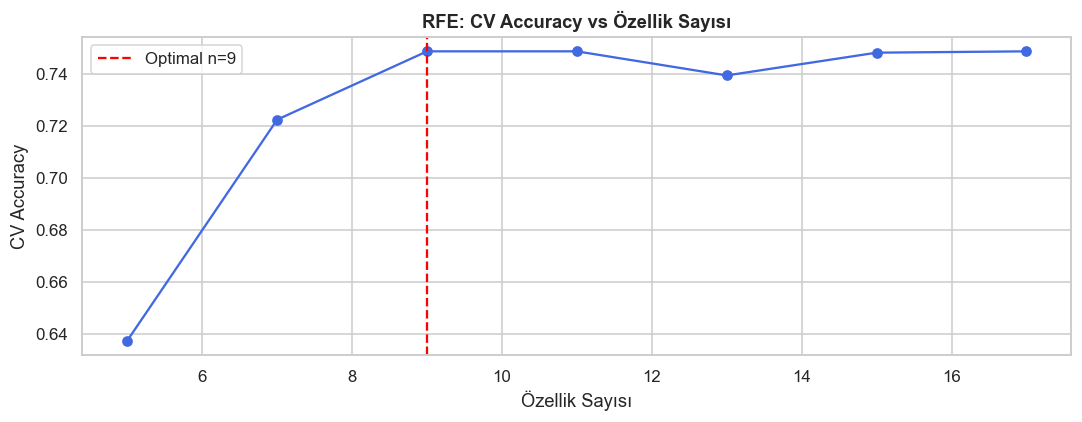

RFE seçilen özellikler (9): ['X_Minimum', 'Orientation_Index', 'LogOfAreas', 'Outside_X_Index', 'Luminosity_Index', 'Steel_Plate_Thickness', 'Minimum_of_Luminosity', 'Pixels_Areas', 'Y_Minimum']


In [20]:
# from sklearn.model_selection import StratifiedKFold
#
# rf_rfe_base   = RandomForestClassifier(n_estimators=50, random_state=SEED, n_jobs=-1)
# cv_rfe        = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
#
# n_features_range = range(5, len(selected_anova) + 1, 2)
# rfe_cv_scores    = {}
#
# for n_feat in n_features_range:
#     rfe_tmp   = RFE(rf_rfe_base, n_features_to_select=n_feat)
#     score_tmp = cross_val_score(rfe_tmp, X_anova, y_enc,
#                                 cv=cv_rfe, scoring='accuracy', n_jobs=-1).mean()
#     rfe_cv_scores[n_feat] = score_tmp
#
# optimal_n = max(rfe_cv_scores, key=rfe_cv_scores.get)
# print(f'RFE optimal özellik sayısı: {optimal_n} (CV acc={rfe_cv_scores[optimal_n]:.4f})')
#
# fig, ax = plt.subplots(figsize=(10, 4))
# ax.plot(list(rfe_cv_scores.keys()), list(rfe_cv_scores.values()),
#         marker='o', color='royalblue')
# ax.axvline(optimal_n, color='red', linestyle='--',
#            label=f'Optimal n={optimal_n}')
# ax.set_xlabel('Özellik Sayısı')
# ax.set_ylabel('CV Accuracy')
# ax.set_title('RFE: CV Accuracy vs Özellik Sayısı', fontweight='bold')
# ax.legend(); plt.tight_layout(); plt.show()
#
# # Final RFE
# rfe_final = RFE(RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
#                 n_features_to_select=optimal_n)
# rfe_final.fit(X_anova, y_enc)
#
# rfe_df = pd.DataFrame({
#     'Özellik'   : X_anova.columns,
#     'RFE Seç'   : rfe_final.support_,
#     'RFE Sıra'  : rfe_final.ranking_,
#     'RF Önemi'  : rf_imp.feature_importances_
# }).sort_values('RFE Sıra').reset_index(drop=True)
#
# selected_rfe  = rfe_df[rfe_df['RFE Seç']]['Özellik'].tolist()
# # print(f'RFE seçilen özellikler ({len(selected_rfe)}): {selected_rfe}')
from sklearn.model_selection import StratifiedKFold

rf_rfe_base   = RandomForestClassifier(n_estimators=50, random_state=SEED, n_jobs=-1)
cv_rfe        = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

n_features_range = range(5, len(X_filtered.columns) + 1, 2)  # 17 üst sınır
rfe_cv_scores    = {}

for n_feat in n_features_range:
    rfe_tmp   = RFE(rf_rfe_base, n_features_to_select=n_feat)
    score_tmp = cross_val_score(rfe_tmp, X_filtered, y_enc,          # ← X_filtered
                                cv=cv_rfe, scoring='accuracy', n_jobs=-1).mean()
    rfe_cv_scores[n_feat] = score_tmp

optimal_n = max(rfe_cv_scores, key=rfe_cv_scores.get)
print(f'RFE optimal özellik sayısı: {optimal_n} (CV acc={rfe_cv_scores[optimal_n]:.4f})')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(list(rfe_cv_scores.keys()), list(rfe_cv_scores.values()),
        marker='o', color='royalblue')
ax.axvline(optimal_n, color='red', linestyle='--',
           label=f'Optimal n={optimal_n}')
ax.set_xlabel('Özellik Sayısı')
ax.set_ylabel('CV Accuracy')
ax.set_title('RFE: CV Accuracy vs Özellik Sayısı', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

# Final RFE
rfe_final = RFE(RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
                n_features_to_select=optimal_n)
rfe_final.fit(X_filtered, y_enc)                                      # ← X_filtered

rfe_df = pd.DataFrame({
    'Özellik'   : X_filtered.columns,                                 # ← X_filtered
    'RFE Seç'   : rfe_final.support_,
    'RFE Sıra'  : rfe_final.ranking_,
}).sort_values('RFE Sıra').reset_index(drop=True)

selected_rfe = rfe_df[rfe_df['RFE Seç']]['Özellik'].tolist()
print(f'RFE seçilen özellikler ({len(selected_rfe)}): {selected_rfe}')

### 2.5 Üç Yöntem Karşılaştırma Tablosu + Oylama

══════════════════════════════════════════════════════════════════════
ÜÇ YÖNTEM KARŞILAŞTIRMA TABLOSU
══════════════════════════════════════════════════════════════════════
                      ANOVA F-testi RF Önemi RFE  Oy Sayısı  Durum
X_Minimum                         ✅        ✅   ✅          3  🏆 3/3
Steel_Plate_Thickness             ✅        ✅   ✅          3  🏆 3/3
Orientation_Index                 ✅        ✅   ✅          3  🏆 3/3
LogOfAreas                        ✅        ✅   ✅          3  🏆 3/3
Outside_X_Index                   ✅        ✅   ✅          3  🏆 3/3
Minimum_of_Luminosity             ✅        ✅   ✅          3  🏆 3/3
Pixels_Areas                      ✅        ✅   ✅          3  🏆 3/3
Edges_Index                       ✅        ✅   ❌          2  ⭐ 2/3
Y_Minimum                         ❌        ✅   ✅          2  ⭐ 2/3
Square_Index                      ✅        ✅   ❌          2  ⭐ 2/3
TypeOfSteel_A300                  ✅        ✅   ❌          2  ⭐ 2/3
Edges_X_Index         

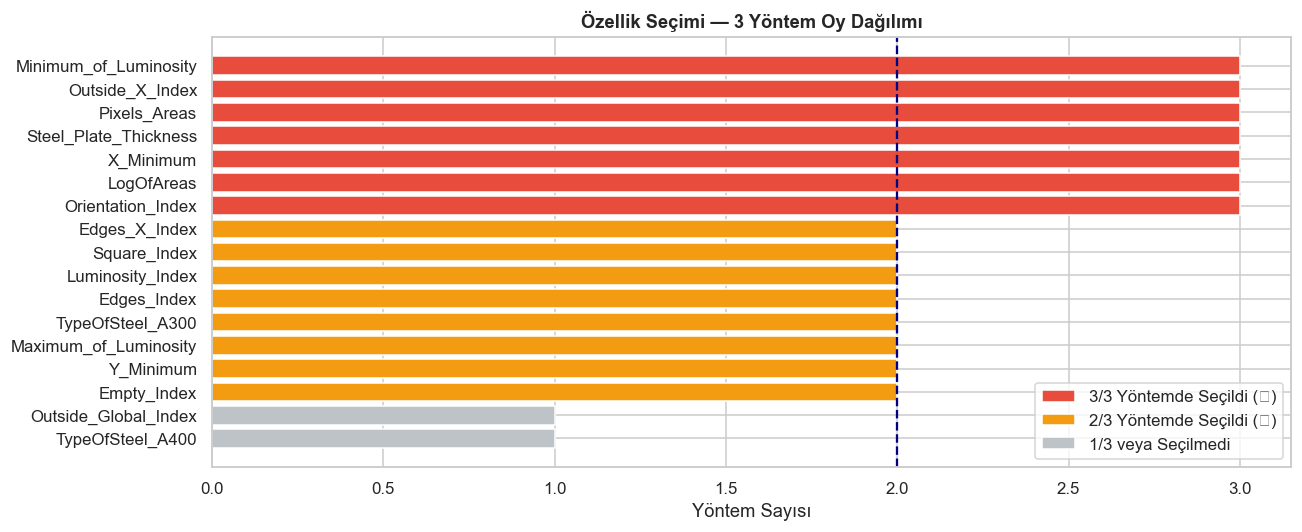


📌 Kırmızı özellikler her 3 yöntemde de seçildi → En güvenilir özellikler
📌 Nihai set: ['Edges_Index', 'Edges_X_Index', 'Empty_Index', 'LogOfAreas', 'Luminosity_Index', 'Maximum_of_Luminosity', 'Minimum_of_Luminosity', 'Orientation_Index', 'Outside_X_Index', 'Pixels_Areas', 'Square_Index', 'Steel_Plate_Thickness', 'TypeOfSteel_A300', 'X_Minimum', 'Y_Minimum']


In [21]:
# ── Karşılaştırma tablosu ─────────────────────────────────────────────
all_feats = X_filtered.columns.tolist()
sets_dict = {
    'ANOVA F-testi' : set(selected_anova),
    'RF Önemi'      : set(selected_rf),
    'RFE'           : set(selected_rfe),
}

comp_df = pd.DataFrame({
    method: ['✅' if f in s else '❌' for f in all_feats]
    for method, s in sets_dict.items()
}, index=all_feats)

votes_dict = {f: sum(1 for s in sets_dict.values() if f in s) for f in all_feats}
comp_df['Oy Sayısı']   = [votes_dict[f] for f in all_feats]
comp_df['Durum']       = comp_df['Oy Sayısı'].map(
    {3: '🏆 3/3', 2: '⭐ 2/3', 1: '➖ 1/3', 0: '❌ 0/3'})
comp_df = comp_df.sort_values('Oy Sayısı', ascending=False)

print('═' * 70)
print('ÜÇ YÖNTEM KARŞILAŞTIRMA TABLOSU')
print('═' * 70)
print(comp_df.to_string())
print('═' * 70)

# Nihai seçim: ≥ 2 yöntemde seçilen
final_features_all = [f for f in all_feats if votes_dict[f] >= 2]
print(f'\n✅ Seçilen nihai özellikler (≥2 oy): {final_features_all}')
print(f'   Boyut: {len(all_feats)} → {len(final_features_all)} özellik')

# Grafik: hangi özellik kaç yöntemde seçildi
fig, ax = plt.subplots(figsize=(12, 5))
vote_series = pd.Series(votes_dict).sort_values(ascending=True)
colors_vote = ['#e74c3c' if v == 3 else '#f39c12' if v == 2
               else '#bdc3c7' for v in vote_series.values]
ax.barh(vote_series.index, vote_series.values,
        color=colors_vote, edgecolor='white')
ax.axvline(2, color='navy', linestyle='--', linewidth=1.5,
           label='Seçim eşiği (2)')
ax.set_xlabel('Yöntem Sayısı')
ax.set_title('Özellik Seçimi — 3 Yöntem Oy Dağılımı', fontweight='bold')
ax.legend()
# Renk açıklaması
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='3/3 Yöntemde Seçildi (🏆)'),
    Patch(facecolor='#f39c12', label='2/3 Yöntemde Seçildi (⭐)'),
    Patch(facecolor='#bdc3c7', label='1/3 veya Seçilmedi'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout(); plt.show()

print('\n📌 Kırmızı özellikler her 3 yöntemde de seçildi → En güvenilir özellikler')
print(f'📌 Nihai set: {sorted(final_features_all)}')


## 📉 Step 3 — Boyut Düşürme (PCA · t-SNE · UMAP)

### 3.1 PCA — Varyans Analizi

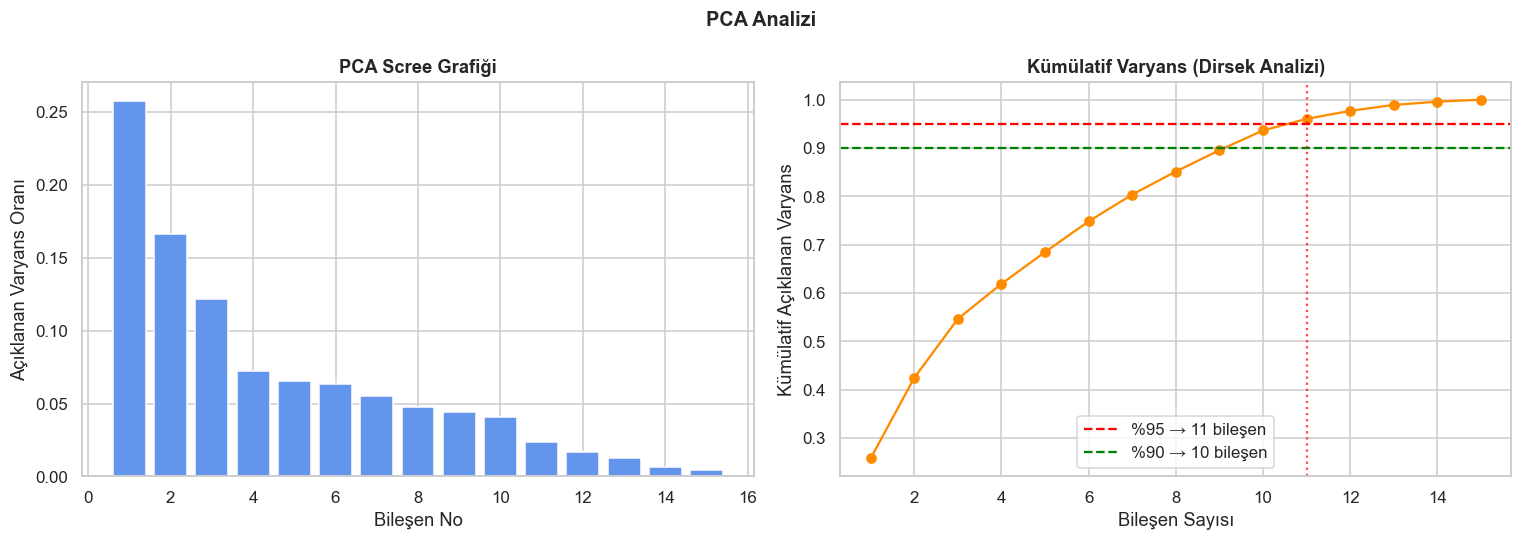

%90 varyans için: 10 bileşen
%95 varyans için: 11 bileşen


In [22]:
X_for_dr = X_filtered[final_features_all].copy()


scaler_pca    = StandardScaler()
X_scaled_pca  = scaler_pca.fit_transform(X_for_dr)

pca_full   = PCA(random_state=SEED)
pca_full.fit(X_scaled_pca)
cum_var    = np.cumsum(pca_full.explained_variance_ratio_)

n_comp_95 = np.argmax(cum_var >= 0.95) + 1
n_comp_90 = np.argmax(cum_var >= 0.90) + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scree
ax1.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
        pca_full.explained_variance_ratio_, color='cornflowerblue')
ax1.set_xlabel('Bileşen No'); ax1.set_ylabel('Açıklanan Varyans Oranı')
ax1.set_title('PCA Scree Grafiği', fontweight='bold')

# Kümülatif
ax2.plot(range(1, len(cum_var) + 1), cum_var, 'o-', color='darkorange')
ax2.axhline(0.95, color='red', linestyle='--', label=f'%95 → {n_comp_95} bileşen')
ax2.axhline(0.90, color='green', linestyle='--', label=f'%90 → {n_comp_90} bileşen')
ax2.axvline(n_comp_95, color='red', linestyle=':', alpha=0.7)
ax2.set_xlabel('Bileşen Sayısı'); ax2.set_ylabel('Kümülatif Açıklanan Varyans')
ax2.set_title('Kümülatif Varyans (Dirsek Analizi)', fontweight='bold')
ax2.legend()

plt.suptitle('PCA Analizi', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'%90 varyans için: {n_comp_90} bileşen')
print(f'%95 varyans için: {n_comp_95} bileşen')

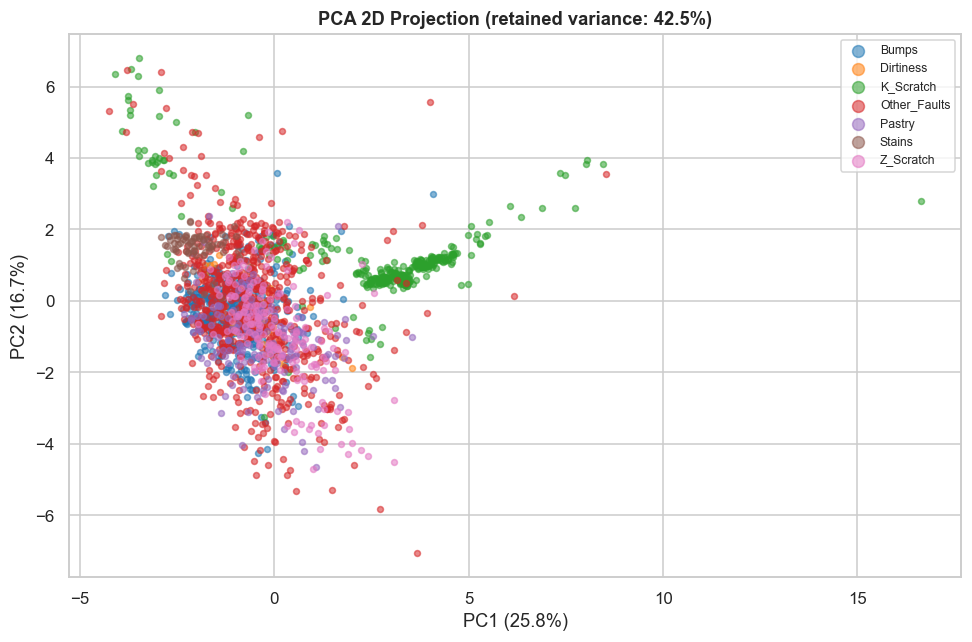

In [23]:
# 2D PCA for visualisation
pca_2d = PCA(n_components=2, random_state=SEED)
X_pca_2d = pca_2d.fit_transform(X_scaled_pca)
retained_2d = pca_2d.explained_variance_ratio_.sum()

fig, ax = plt.subplots(figsize=(9, 6))
palette = sns.color_palette('tab10', n_classes)
for i, cls in enumerate(class_names):
    mask = y_enc == i
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               label=cls, alpha=0.55, s=15, color=palette[i])
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'PCA 2D Projection (retained variance: {retained_2d*100:.1f}%)', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

### 3.2 t-SNE (perplexity: 15, 30, 50)

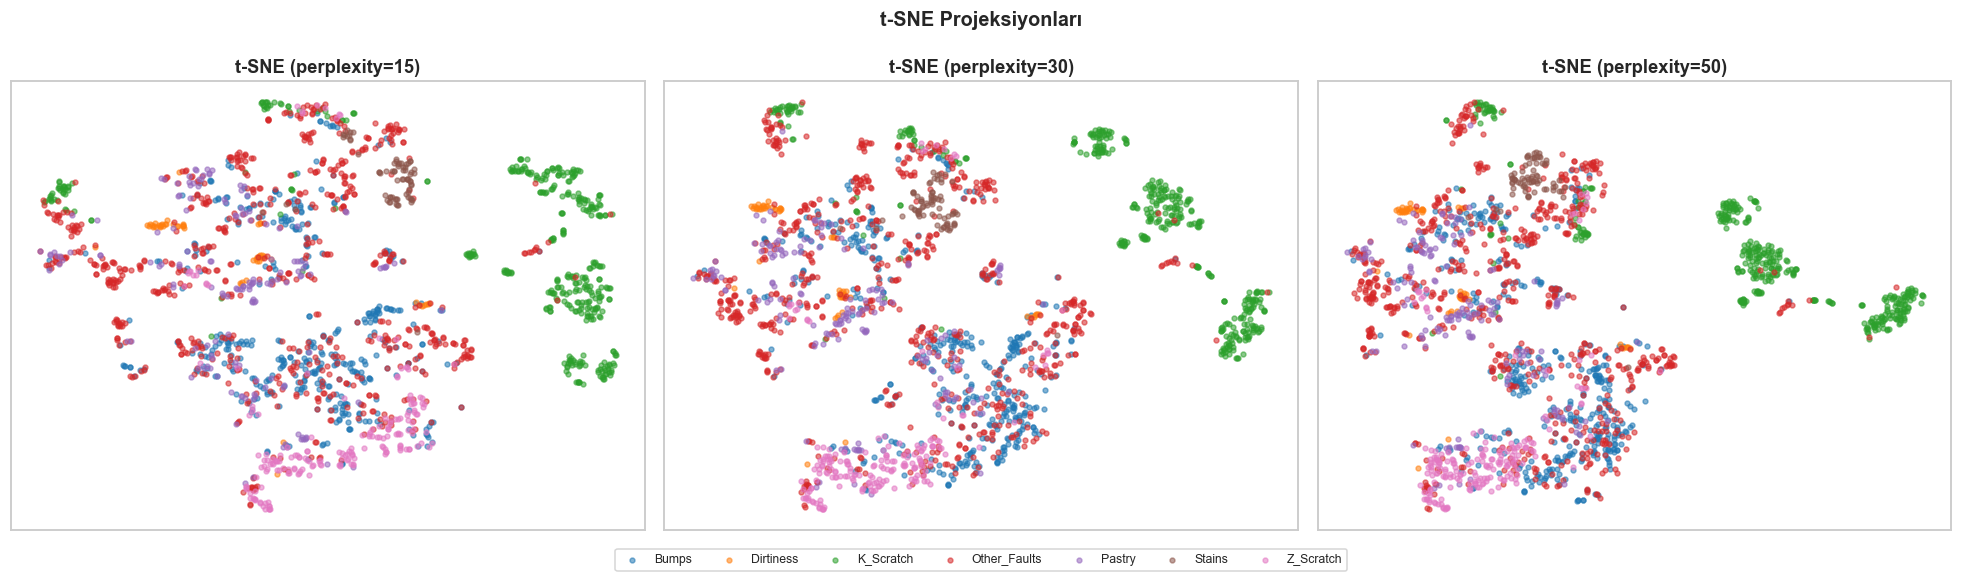

In [24]:
perplexities = [15, 30, 50]
fig, axes    = plt.subplots(1, 3, figsize=(18, 5))

for ax, perp in zip(axes, perplexities):
    tsne   = TSNE(n_components=2, perplexity=perp, random_state=SEED, max_iter=1000)
    X_tsne = tsne.fit_transform(X_scaled_pca)
    for i, cls in enumerate(class_names):
        mask = y_enc == i
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   label=cls, alpha=0.55, s=10, color=palette[i])
    ax.set_title(f't-SNE (perplexity={perp})', fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=n_classes,
           fontsize=8, bbox_to_anchor=(0.5, -0.05))
plt.suptitle('t-SNE Projeksiyonları', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 3.3 UMAP

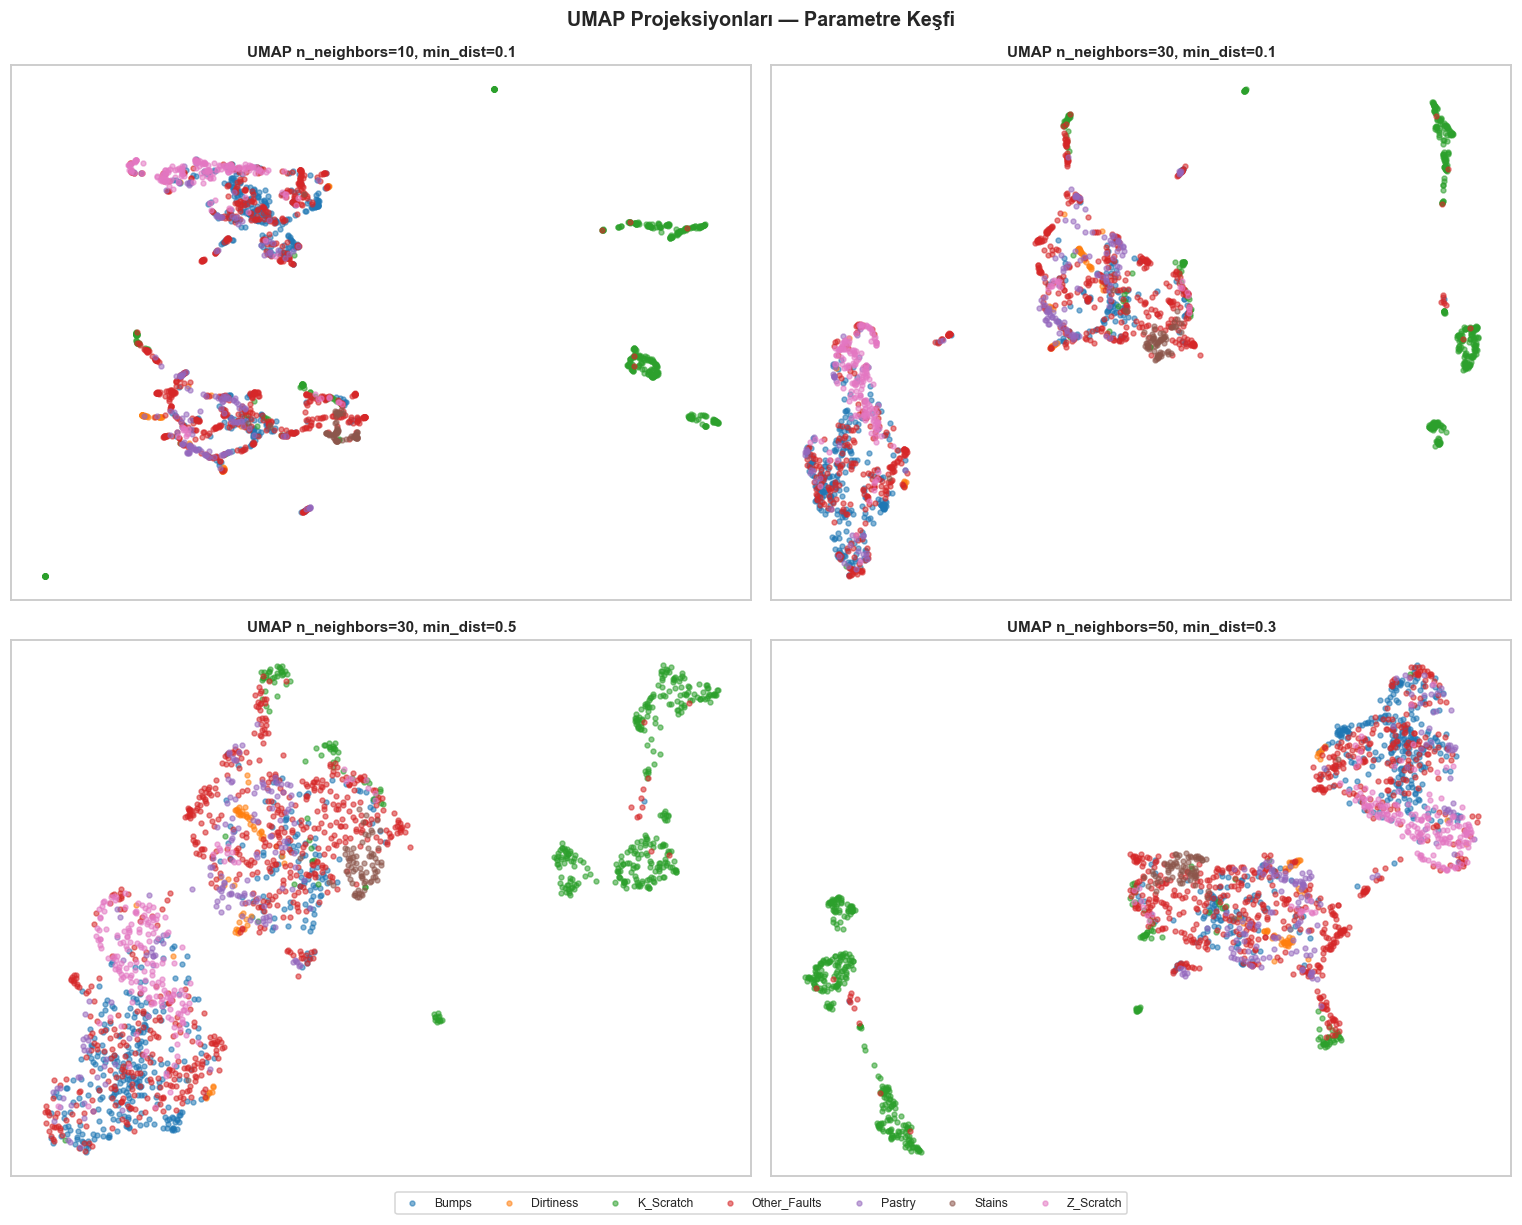

In [25]:
umap_params = [
    {'n_neighbors': 10, 'min_dist': 0.1},
    {'n_neighbors': 30, 'min_dist': 0.1},
    {'n_neighbors': 30, 'min_dist': 0.5},
    {'n_neighbors': 50, 'min_dist': 0.3},
]
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes      = axes.flatten()

for ax, params in zip(axes, umap_params):
    reducer = umap.UMAP(n_components=2, random_state=SEED, **params)
    X_umap  = reducer.fit_transform(X_scaled_pca)
    for i, cls in enumerate(class_names):
        mask = y_enc == i
        ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
                   label=cls, alpha=0.55, s=10, color=palette[i])
    ax.set_title(f'UMAP n_neighbors={params["n_neighbors"]}, min_dist={params["min_dist"]}',
                 fontsize=10, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=n_classes,
           fontsize=8, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('UMAP Projeksiyonları — Parametre Keşfi', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

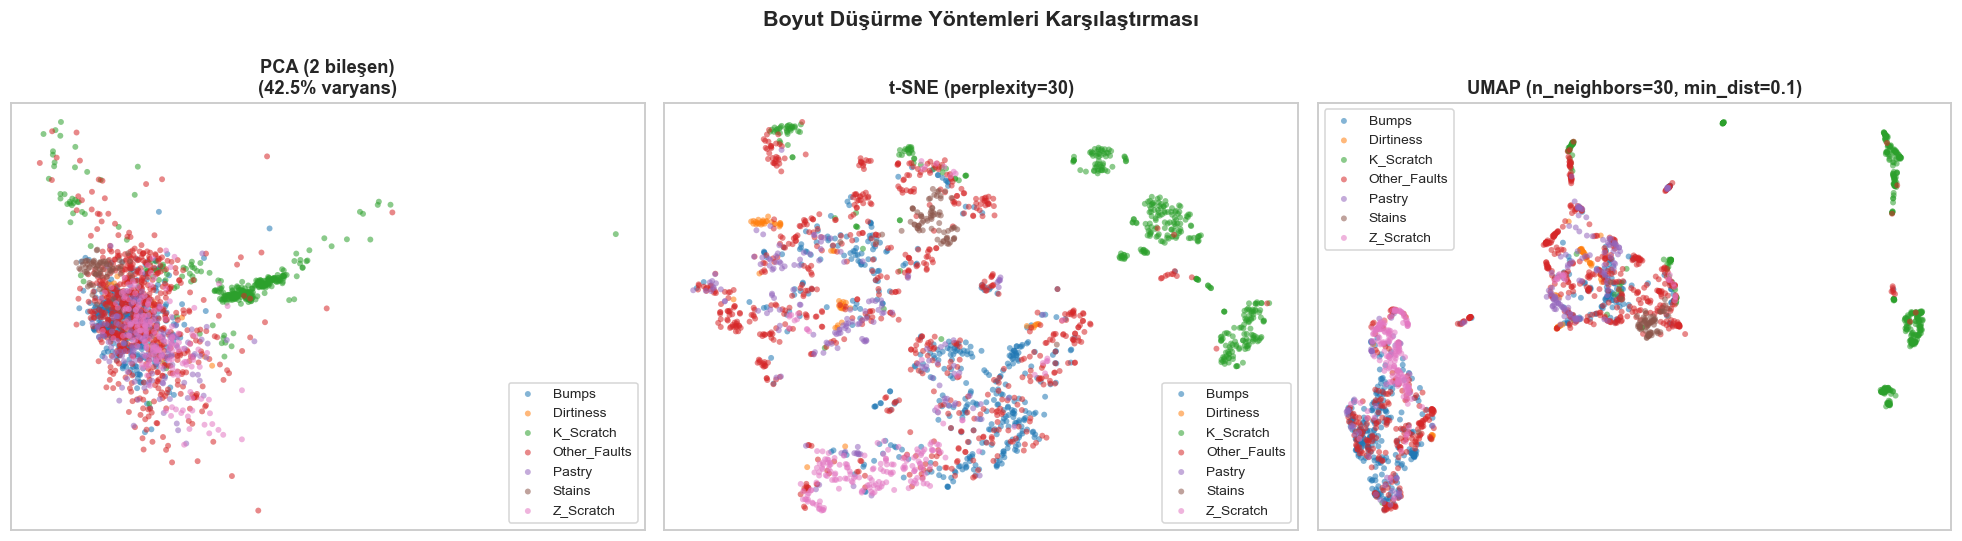

📌 PCA doğrusal ayrımı gösterirken t-SNE ve UMAP yerel küme yapısını daha net ortaya çıkarır.


In [26]:
# ── PCA · t-SNE · UMAP Yan Yana Karşılaştırma ────────────────────────
# PCA 2 bileşen (görselleştirme için)
pca_2d       = PCA(n_components=2, random_state=SEED)
emb_pca2     = pca_2d.fit_transform(X_scaled_pca)

# t-SNE — en iyi perplexity=30
tsne_best    = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
emb_tsne_best = tsne_best.fit_transform(X_scaled_pca)

# UMAP — en iyi parametreler
reducer_best  = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=SEED)
emb_umap_best = reducer_best.fit_transform(X_scaled_pca)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Boyut Düşürme Yöntemleri Karşılaştırması', fontsize=14, fontweight='bold')

infos = [
    (emb_pca2,        f'PCA (2 bileşen)\n({pca_2d.explained_variance_ratio_.sum()*100:.1f}% varyans)'),
    (emb_tsne_best,   't-SNE (perplexity=30)'),
    (emb_umap_best,   'UMAP (n_neighbors=30, min_dist=0.1)'),
]

for ax, (emb, title) in zip(axes, infos):
    for i, cls in enumerate(class_names):
        mask = y_enc == i
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=palette[i], label=cls,
                   alpha=0.55, s=15, edgecolors='none')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()
print('📌 PCA doğrusal ayrımı gösterirken t-SNE ve UMAP yerel küme yapısını daha net ortaya çıkarır.')

## ⚖️ Step 4 — Train/Test Ayrımı + SMOTE Öncesi / Sonrası Karşılaştırması

**Bu bölümde SMOTE'un model performansına etkisi sayısal ve görsel olarak gösterilir.**  
Her model hem ham (SMOTE öncesi) hem de SMOTE sonrası veriyle eğitilir, fark hesaplanır.


### 4.1 Train/Test Ayrımı ve Ölçekleme

In [27]:
X_model_base = X_filtered[final_features_all].copy()  # ← X_anova → X_filtered

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_model_base, y_enc,
    test_size=0.2, random_state=SEED, stratify=y_enc
)
print(f'Eğitim: {X_train_raw.shape}  |  Test: {X_test_raw.shape}')

# Ölçekleme (sadece eğitim üzerinde fit)
scaler        = StandardScaler()
X_train_sc    = scaler.fit_transform(X_train_raw)
X_test_sc     = scaler.transform(X_test_raw)

print(f'Ölçekleme tamamlandı. Eğitim: {X_train_sc.shape} | Test: {X_test_sc.shape}')

Eğitim: (1552, 15)  |  Test: (389, 15)
Ölçekleme tamamlandı. Eğitim: (1552, 15) | Test: (389, 15)


## 🔧 Step 5 — Hiperparametre Optimizasyonu (optuna)

In [28]:
import optuna
from optuna.samplers import TPESampler
from optuna.pruners  import MedianPruner
from sklearn.model_selection import StratifiedKFold, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def objective_lgbm(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth'        : trial.suggest_int('max_depth', -1, 15),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'class_weight'     : 'balanced',   # Dengeleme algoritma seviyesinde
        'random_state'     : SEED, 'n_jobs': -1, 'verbose': -1,
    }
    clf    = lgb.LGBMClassifier(**params)
    scores = cross_val_score(clf, X_train_sc, y_train,
                              cv=cv5, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

def objective_svm(trial):
    kernel = trial.suggest_categorical('kernel', ['rbf', 'poly'])
    params = {
        'C'           : trial.suggest_float('C', 0.01, 100, log=True),
        'gamma'       : trial.suggest_categorical('gamma', ['scale', 'auto']),
        'kernel'      : kernel,
        'class_weight': 'balanced',
        'probability' : True,
        'random_state': SEED,
    }
    if kernel == 'poly':
        params['degree'] = trial.suggest_int('degree', 2, 4)
    clf    = SVC(**params)
    # DÜZELTME: X_train_sc, y_train ve f1_macro
    scores = cross_val_score(clf, X_train_sc, y_train,
                              cv=cv5, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 25),
        'weights'    : trial.suggest_categorical('weights', ['uniform', 'distance']),
        'metric'     : trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'minkowski']),
        'n_jobs'     : -1,
    }
    clf    = KNeighborsClassifier(**params)
    # DÜZELTME: X_train_sc, y_train ve f1_macro
    scores = cross_val_score(clf, X_train_sc, y_train,
                              cv=cv5, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

def objective_svm_linear(trial):
    params = {
        'C'           : trial.suggest_float('C', 0.001, 100, log=True),
        'max_iter'    : trial.suggest_int('max_iter', 1000, 5000, step=500),
        'kernel'      : 'linear',
        'class_weight': 'balanced',
        'probability' : True,
        'random_state': SEED,
    }
    clf    = SVC(**params)
    # DÜZELTME: y_train_sc -> y_train yapıldı, f1_macro eklendi
    scores = cross_val_score(clf, X_train_sc, y_train,
                              cv=cv5, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

# ─── Model-objective eşleştirmesi ───────────────────────────────────────────
objectives_map = {
    'LightGBM'  : (objective_lgbm,       lgb.LGBMClassifier),
    'SVM Linear': (objective_svm_linear, SVC),
    'SVM RBF'   : (objective_svm,        SVC),
    'k-NN'      : (objective_knn,        KNeighborsClassifier),
}

N_TRIALS = 40

trained_models  = {}
best_params_all = {}
optuna_studies  = {}

print(f'{"="*65}')
print(f'  OPTUNA HİPERPARAMETRE OPTİMİZASYONU  —  {N_TRIALS} trial/model')
print(f'{"="*65}')

for model_name, (objective_fn, model_cls) in objectives_map.items():
    print(f'\n▶ {model_name} optimize ediliyor (f1_macro hedefleniyor)...')

    study = optuna.create_study(
        direction='maximize',
        sampler=TPESampler(seed=SEED),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=3),
        study_name=model_name,
    )
    study.optimize(objective_fn, n_trials=N_TRIALS, show_progress_bar=False)

    best_params = study.best_params
    best_score  = study.best_value

    clf = model_cls(**{k: v for k, v in best_params.items()
                        if k in model_cls().get_params()},
                    **({'random_state'  : SEED}        if 'random_state'   in model_cls().get_params() else {}),
                    **({'n_jobs'        : -1}           if 'n_jobs'         in model_cls().get_params() else {}),
                    **({'verbose'       : 0}           if 'verbose'        in model_cls().get_params() else {}),
                    **({'probability'   : True}         if model_cls == SVC else {}),
                    **({'class_weight'  : 'balanced'}   if model_cls in [SVC, lgb.LGBMClassifier] else {}))

    # DÜZELTME: Model artık SMOTE görmemiş orijinal X_train_sc ile eğitiliyor
    clf.fit(X_train_sc, y_train)

    trained_models[model_name]  = clf
    best_params_all[model_name] = best_params
    optuna_studies[model_name]  = study

    print(f'  ✅ En iyi CV F1 (macro): {best_score:.4f}')
    print(f'  📌 Parametreler : {best_params}')

print(f'\n{"="*65}')
print('✅ Tüm modeller Optuna ile SMOTE olmadan başarıyla optimize edildi.')
print(f'{"="*65}')

  OPTUNA HİPERPARAMETRE OPTİMİZASYONU  —  40 trial/model

▶ LightGBM optimize ediliyor (f1_macro hedefleniyor)...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000653 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2996
[LightGBM] [Info] Number of data points in the train set: 1552, number of used features: 15
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

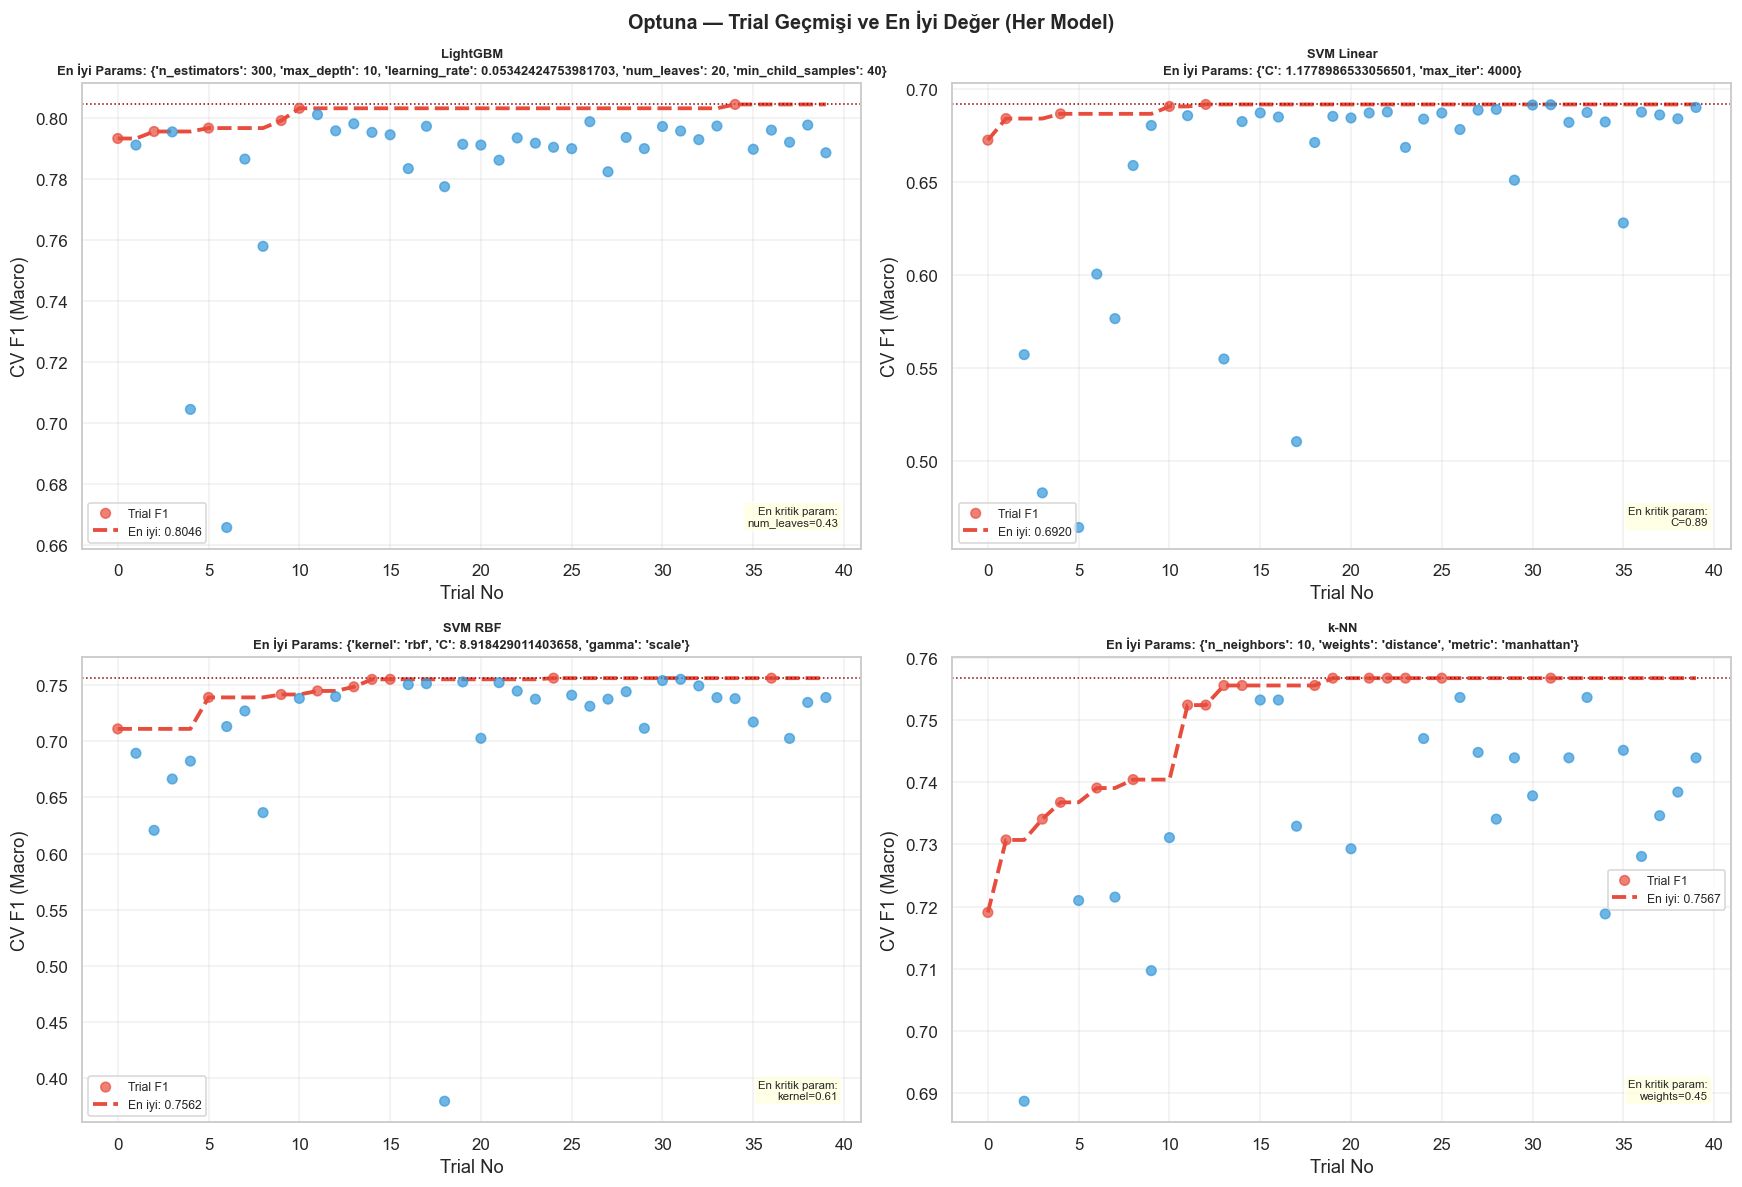


─── Optuna Sonuçları Özet Tablosu ───
     Model  N Trials  En İyi CV F1  Ort. Trial F1  Std Trial F1 Yüksek Önem Param
  LightGBM        40        0.8046         0.7872        0.0250        num_leaves
      k-NN        40        0.7567         0.7405        0.0152           weights
   SVM RBF        40        0.7562         0.7196        0.0628            kernel
SVM Linear        40        0.6920         0.6558        0.0601                 C

📌 TPE Sampler önceki başarılı parametrelerden öğrenerek arama bölgesini daraltır.
   Bu nedenle trial ilerledikçe F1 değerleri daha tutarlı yükselir (kırmızı çizgi).


In [29]:
# ── Optuna Sonuçları Görselleştirme ─────────────────────────────────────────
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax, (model_name, study) in zip(axes, optuna_studies.items()):
    trials_df = study.trials_dataframe()

    # Trial bazlı F1 gelişimi
    values = trials_df['value'].values
    best_so_far = np.maximum.accumulate(values)

    ax.scatter(range(len(values)), values,
               c=['#3498db' if v < best_so_far[i] else '#e74c3c'
                  for i, v in enumerate(values)],
               alpha=0.7, s=40, zorder=3, label='Trial F1')
    ax.plot(range(len(best_so_far)), best_so_far,
            color='#e74c3c', lw=2.5, linestyle='--',
            label=f'En iyi: {study.best_value:.4f}')
    ax.axhline(study.best_value, color='darkred', lw=1, linestyle=':')
    ax.set_title(f'{model_name}\nEn İyi Params: {study.best_params}',
                 fontsize=8.5, fontweight='bold')
    ax.set_xlabel('Trial No')
    ax.set_ylabel('CV F1 (Macro)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Parametre önem skoru (varsa)
    try:
        importances = optuna.importance.get_param_importances(study)
        top_param   = max(importances, key=importances.get)
        ax.annotate(f'En kritik param:\n{top_param}={importances[top_param]:.2f}',
                    xy=(0.97, 0.05), xycoords='axes fraction',
                    ha='right', fontsize=7.5,
                    bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8))
    except Exception:
        pass

plt.suptitle('Optuna — Trial Geçmişi ve En İyi Değer (Her Model)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Karşılaştırma tablosu ────────────────────────────────────────────────────
print('\n─── Optuna Sonuçları Özet Tablosu ───')
summary_rows = []
for model_name, study in optuna_studies.items():
    vals = [t.value for t in study.trials if t.value is not None]
    summary_rows.append({
        'Model'           : model_name,
        'N Trials'        : len(vals),
        'En İyi CV F1'    : round(study.best_value, 4),
        'Ort. Trial F1'   : round(np.mean(vals), 4),
        'Std Trial F1'    : round(np.std(vals), 4),
        'Yüksek Önem Param': (
            max(optuna.importance.get_param_importances(study),
                key=optuna.importance.get_param_importances(study).get)
            if len(vals) > 5 else '—'
        ),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('En İyi CV F1', ascending=False)
print(summary_df.to_string(index=False))

print('\n📌 TPE Sampler önceki başarılı parametrelerden öğrenerek arama bölgesini daraltır.')
print('   Bu nedenle trial ilerledikçe F1 değerleri daha tutarlı yükselir (kırmızı çizgi).')

## 🧪 Step 6 — Üç Veri Temsiliyle Model Eğitimi ve Karşılaştırma

**Her model aynı hiperparametrelerle üç farklı veri temsiliyle eğitilir:**
1. **Ham (Tüm Seçilen)** — Step 2'de oylama ile belirlenen `final_features_all`  
2. **Seçilen Özellikler** — Aynı set (burada ANOVA → RF → RFE oylama sonucu)  
3. **PCA** — %95 varyansı koruyan bileşenler

> *Ham ve seçilen aynı başlangıç noktasından gelmektedir; aralarındaki fark PCA transformasyonunun etkisiyle kıyaslanır.*


### 6.1 Veri Setlerini Hazırla

In [30]:
# ── Veri Seti 1: Seçilen Özellikler ─────────────────────────────────
# X_train_sc, X_test_sc, y_train, y_test zaten hazır (Step 4'ten)

# ── Veri Seti 2: Tüm Ham Özellikler (Pearson+Cosine/ANOVA/RF/RFE öncesi) ──
# X = KNNImputer sonrası tam ham veri, hiçbir filtreleme yapılmamış
X_all = X.copy()

X_train_all_raw, X_test_all_raw, _, _ = train_test_split(
    X_all, y_enc, test_size=0.2, random_state=SEED, stratify=y_enc
)
scaler_all     = StandardScaler()
X_train_all_sc = scaler_all.fit_transform(X_train_all_raw)
X_test_all_sc  = scaler_all.transform(X_test_all_raw)

print(f'Veri Seti 1 — Seçilen Özellikler : {X_train_sc.shape}')
print(f'Veri Seti 2 — Tüm Ham Özellikler : {X_train_all_sc.shape}')

# ── Veri Seti 3: PCA ─────────────────────────────────────────────────
pca_model   = PCA(n_components=n_comp_95, random_state=SEED)
X_train_pca = pca_model.fit_transform(X_train_sc)
X_test_pca  = pca_model.transform(X_test_sc)

print(f'Veri Seti 3 — PCA ({n_comp_95} bileşen)     : {X_train_pca.shape}')
print(f'   Korunan Varyans: %{pca_model.explained_variance_ratio_.sum()*100:.2f}')

Veri Seti 1 — Seçilen Özellikler : (1552, 15)
Veri Seti 2 — Tüm Ham Özellikler : (1552, 27)
Veri Seti 3 — PCA (11 bileşen)     : (1552, 11)
   Korunan Varyans: %96.85


### 6.2 En İyi Model ile Üç Veri Seti Üzerinde Eğitim

In [31]:
# En iyi model olarak LightGBM kullanıyoruz (en güçlü genellikle o)
# Her veri seti için ayrı model nesnesi

best_model_cls    = lgb.LGBMClassifier
best_model_params = best_params_all.get('LightGBM', {
    'n_estimators': 200, 'max_depth': -1,
    'learning_rate': 0.1, 'num_leaves': 63
})

datasets = {
    'Tüm Özellikler'    : (X_train_all_sc, y_train, X_test_all_sc),
    'Seçilen Özellikler': (X_train_sc,     y_train, X_test_sc),
    f'PCA ({n_comp_95} bileşen)': (X_train_pca, y_train, X_test_pca),
}

y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

repr_results = []
repr_models  = {}
repr_preds   = {}
repr_probs   = {}

for ds_name, (X_tr, y_tr, X_te) in datasets.items():
    print(f'\n── {ds_name} ({X_tr.shape[1]} boyut) ──')
    clf = lgb.LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1,
                              class_weight='balanced',   # ← eklendi
                              **best_model_params)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    y_prob = clf.predict_proba(X_te)

    repr_models[ds_name] = clf
    repr_preds[ds_name]  = y_pred
    repr_probs[ds_name]  = y_prob

    try:
        auc_roc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='weighted')
    except Exception:
        auc_roc = np.nan

    cv_sc = cross_val_score(clf, X_tr, y_tr, cv=cv5, scoring='f1_macro', n_jobs=-1)  # ← f1_macro

    row = {
        'Veri Temsili'   : ds_name,
        'Boyut'          : X_tr.shape[1],
        'Test Accuracy'  : round(accuracy_score(y_test, y_pred), 4),
        'Test F1 (Mac)'  : round(f1_score(y_test, y_pred, average='macro'), 4),       # ← macro
        'Test F1 (W)'    : round(f1_score(y_test, y_pred, average='weighted'), 4),
        'Test Precision' : round(precision_score(y_test, y_pred, average='macro',
                                                 zero_division=0), 4),                # ← macro
        'Test Recall'    : round(recall_score(y_test, y_pred, average='macro'), 4),   # ← macro
        'AUC-ROC'        : round(auc_roc, 4) if not np.isnan(auc_roc) else 'N/A',
        'CV F1 Mac Ort.' : round(cv_sc.mean(), 4),
        'CV F1 Mac Std'  : round(cv_sc.std(), 4),
    }
    repr_results.append(row)
    print(f'  Test F1 (Mac): {row["Test F1 (Mac)"]:.4f}  |  '
          f'Test F1 (W): {row["Test F1 (W)"]:.4f}  |  '
          f'AUC-ROC: {row["AUC-ROC"]}  |  Boyut: {X_tr.shape[1]}')

repr_df = pd.DataFrame(repr_results)

print('\n' + '='*95)
print('TÜM ÖZELLİKLER vs SEÇİLEN ÖZELLİKLER vs PCA — KARŞILAŞTIRMA TABLOSU')
print('='*95)
print(repr_df.to_string(index=False))
print('='*95)


── Tüm Özellikler (27 boyut) ──
  Test F1 (Mac): 0.8291  |  Test F1 (W): 0.8214  |  AUC-ROC: 0.9487  |  Boyut: 27

── Seçilen Özellikler (15 boyut) ──
  Test F1 (Mac): 0.7840  |  Test F1 (W): 0.7685  |  AUC-ROC: 0.9368  |  Boyut: 15

── PCA (11 bileşen) (11 boyut) ──
  Test F1 (Mac): 0.7149  |  Test F1 (W): 0.7165  |  AUC-ROC: 0.9048  |  Boyut: 11

TÜM ÖZELLİKLER vs SEÇİLEN ÖZELLİKLER vs PCA — KARŞILAŞTIRMA TABLOSU
      Veri Temsili  Boyut  Test Accuracy  Test F1 (Mac)  Test F1 (W)  Test Precision  Test Recall  AUC-ROC  CV F1 Mac Ort.  CV F1 Mac Std
    Tüm Özellikler     27         0.8201         0.8291       0.8214          0.8264       0.8334   0.9487          0.8094         0.0133
Seçilen Özellikler     15         0.7661         0.7840       0.7685          0.7814       0.7909   0.9368          0.8046         0.0196
  PCA (11 bileşen)     11         0.7147         0.7149       0.7165          0.7410       0.6934   0.9048          0.7194         0.0165


### 6.3 Karşılaştırma Görselleştirmesi

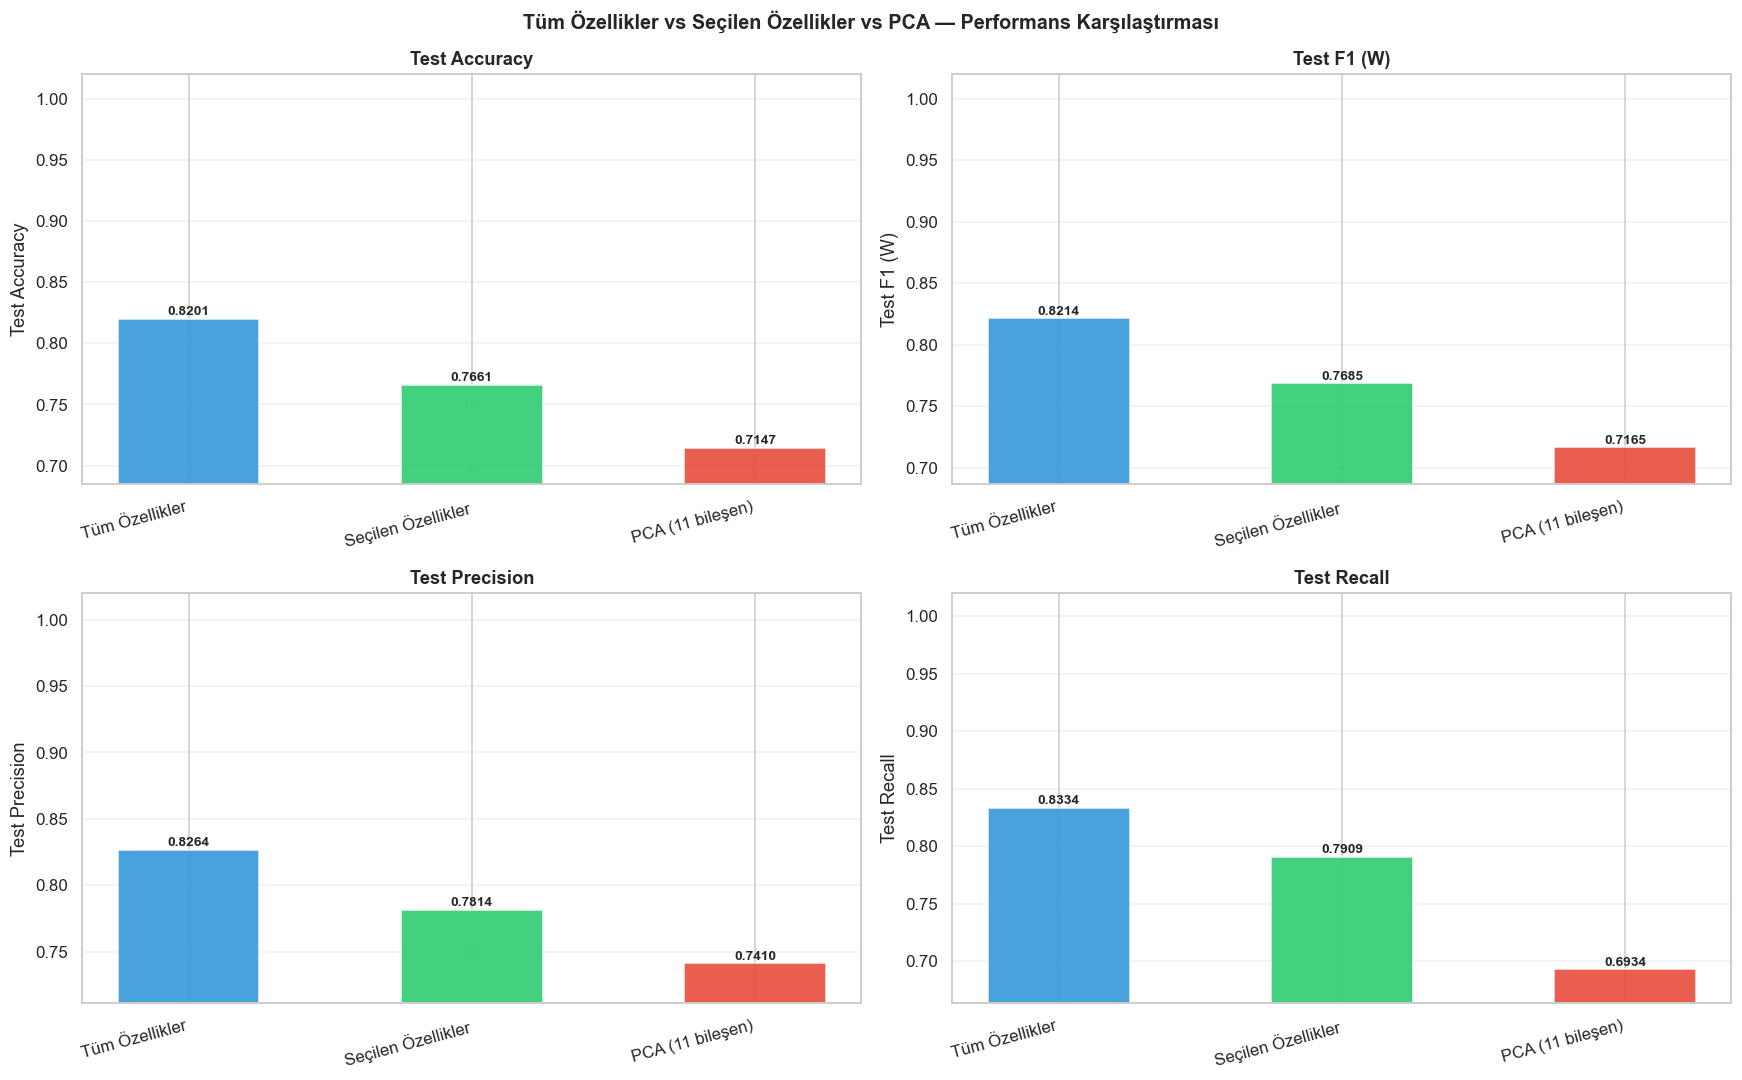


🏆 En iyi veri temsili: Tüm Özellikler
   Test F1 (Weighted): 0.8214


In [32]:
metrics_plot = ['Test Accuracy', 'Test F1 (W)', 'Test Precision', 'Test Recall']
x_pos        = np.arange(len(repr_df))
bar_colors   = ['#3498db', '#2ecc71', '#e74c3c']
bar_width    = 0.22

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes      = axes.flatten()

for ax, metric in zip(axes, metrics_plot):
    vals  = repr_df[metric].astype(float)
    bars  = ax.bar(x_pos, vals, color=bar_colors, edgecolor='white',
                   width=0.5, alpha=0.9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(repr_df['Veri Temsili'], rotation=15, ha='right')
    ax.set_ylim(vals.min() - 0.03, 1.02)
    ax.set_ylabel(metric)
    ax.set_title(metric, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Tüm Özellikler vs Seçilen Özellikler vs PCA — Performans Karşılaştırması',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# En iyi veri temsili
best_repr = repr_df.sort_values('Test F1 (W)', ascending=False).iloc[0]
print(f'\n🏆 En iyi veri temsili: {best_repr["Veri Temsili"]}')
print(f'   Test F1 (Weighted): {best_repr["Test F1 (W)"]}')

## 📋 Step 7 — Tüm Modeller Değerlendirme

In [33]:
all_results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test_sc)

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)

    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_sc)
        try:
            auc_roc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='weighted')
        except Exception:
            auc_roc = np.nan
    elif hasattr(model, 'decision_function'):
        y_df = model.decision_function(X_test_sc)
        try:
            auc_roc = roc_auc_score(y_test_bin, y_df, multi_class='ovr', average='weighted')
        except Exception:
            auc_roc = np.nan
    else:
        auc_roc = np.nan

    cv_sc = cross_val_score(model, X_train_sc, y_train,
                             cv=cv5, scoring='f1_weighted', n_jobs=-1)

    all_results.append({
        'Model'           : name,
        'Test Accuracy'   : round(acc, 4),
        'Test F1 (W)'     : round(f1, 4),
        'Test Precision'  : round(prec, 4),
        'Test Recall'     : round(rec, 4),
        'AUC-ROC'         : round(auc_roc, 4) if not np.isnan(auc_roc) else 'N/A',
        'CV F1 Ort.'      : round(cv_sc.mean(), 4),
        'CV F1 Std'       : round(cv_sc.std(), 4),
    })

all_results_df = pd.DataFrame(all_results).sort_values('Test F1 (W)', ascending=False)
print('\n=== Tüm Modeller Performans Tablosu ===')
print(all_results_df.to_string(index=False))

best_model_name = all_results_df.iloc[0]['Model']
print(f'\n★ En iyi model (Test F1 Weighted): {best_model_name}')


=== Tüm Modeller Performans Tablosu ===
     Model  Test Accuracy  Test F1 (W)  Test Precision  Test Recall  AUC-ROC  CV F1 Ort.  CV F1 Std
  LightGBM         0.7661       0.7685          0.7740       0.7661   0.9368      0.7787     0.0108
      k-NN         0.7172       0.7175          0.7215       0.7172   0.9089      0.7383     0.0067
   SVM RBF         0.7121       0.7140          0.7351       0.7121   0.9241      0.7282     0.0185
SVM Linear         0.6838       0.6868          0.7171       0.6838   0.9151      0.7123     0.0198

★ En iyi model (Test F1 Weighted): LightGBM


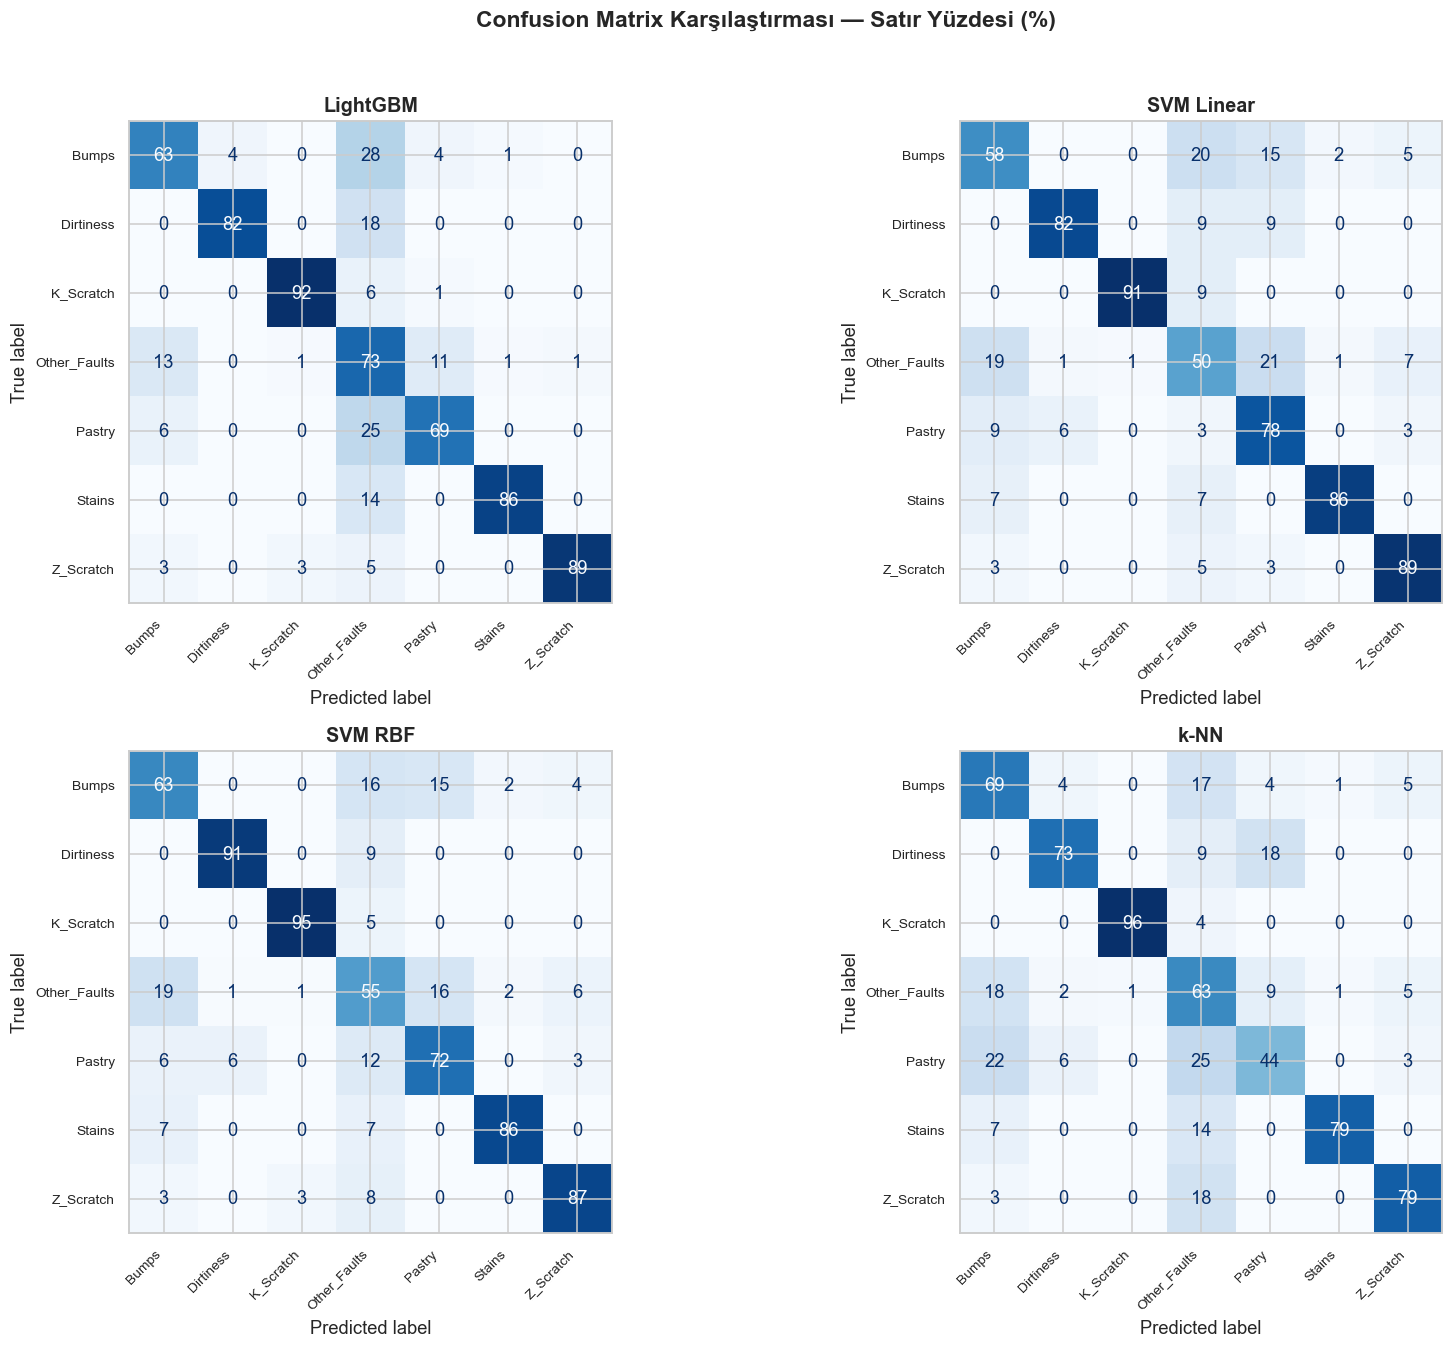

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = ['Bumps','Dirtiness','K_Scratch','Other_Faults','Pastry','Stains','Z_Scratch']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred)

    # Satır yüzdesi (recall bazlı)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    disp = ConfusionMatrixDisplay(confusion_matrix=cm_pct,
                                   display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.0f')
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(class_names, fontsize=9)

plt.suptitle('Confusion Matrix Karşılaştırması — Satır Yüzdesi (%)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 🎯 Step 8 — Final Karşılaştırmalı Görselleştirme

**SMOTE + Seçilen Özellik + PCA ile eğitilen üç modelin:**
- Confusion Matrix karşılaştırması  
- Precision-Recall eğrileri  
- ROC AUC eğrileri


### 8.1 Confusion Matrix Karşılaştırması

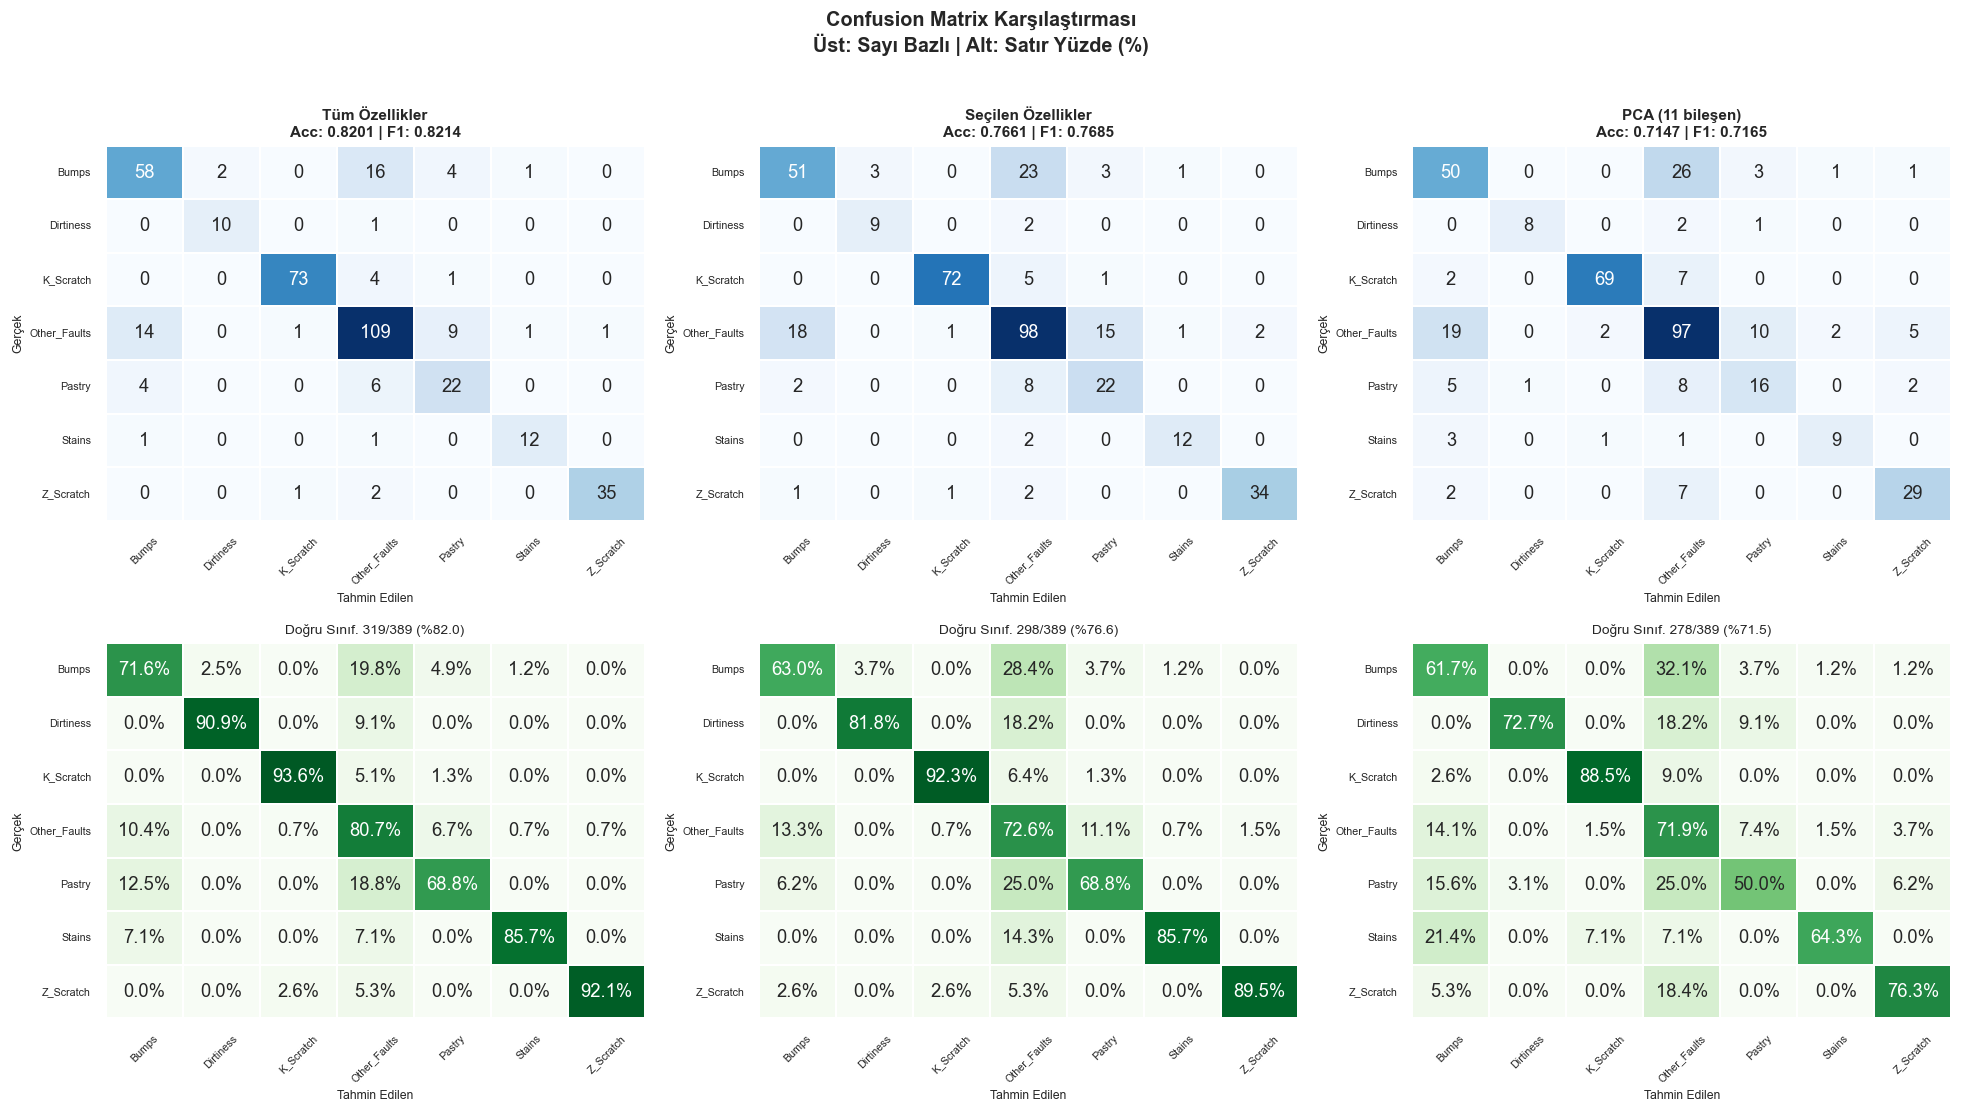

📌 Köşegen dışı hücreler yanlış sınıflandırmaları gösterir; "Other_Faults" en çok karıştırılan sınıftır.


In [35]:
# Her veri temsili için LightGBM sonuçlarını al
final_comparisons = {
    ds: (repr_preds[ds], repr_probs[ds])
    for ds in datasets.keys()
}

n_ds   = len(final_comparisons)
ncols_cm = 3
nrows_cm = 2
fig, axes = plt.subplots(nrows_cm, ncols_cm, figsize=(ncols_cm * 6, nrows_cm * 5))

for col_idx, (ds_name, (y_pred_ds, y_prob_ds)) in enumerate(final_comparisons.items()):
    cm     = confusion_matrix(y_test, y_pred_ds)
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

    f1_ds  = f1_score(y_test, y_pred_ds, average='weighted')
    acc_ds = accuracy_score(y_test, y_pred_ds)

    # Üst satır: mutlak sayı
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[0, col_idx], linewidths=0.3, cbar=False)
    axes[0, col_idx].set_title(
        f'{ds_name}\nAcc: {acc_ds:.4f} | F1: {f1_ds:.4f}',
        fontweight='bold', fontsize=10
    )
    axes[0, col_idx].set_xlabel('Tahmin Edilen', fontsize=8)
    axes[0, col_idx].set_ylabel('Gerçek', fontsize=8)
    axes[0, col_idx].tick_params(axis='x', rotation=45, labelsize=7)
    axes[0, col_idx].tick_params(axis='y', rotation=0, labelsize=7)

    # Alt satır: yüzde bazlı
    annot_pct = np.array([[f'{v:.1f}%' for v in row] for row in cm_pct])
    sns.heatmap(cm_pct, annot=annot_pct, fmt='', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[1, col_idx], linewidths=0.3,
                vmin=0, vmax=100, cbar=False)
    tn_sum = cm.diagonal().sum()
    axes[1, col_idx].set_title(
        f'Doğru Sınıf. {tn_sum}/{len(y_test)} (%{tn_sum/len(y_test)*100:.1f})',
        fontsize=9
    )
    axes[1, col_idx].set_xlabel('Tahmin Edilen', fontsize=8)
    axes[1, col_idx].set_ylabel('Gerçek', fontsize=8)
    axes[1, col_idx].tick_params(axis='x', rotation=45, labelsize=7)
    axes[1, col_idx].tick_params(axis='y', rotation=0, labelsize=7)

plt.suptitle(
    'Confusion Matrix Karşılaştırması\nÜst: Sayı Bazlı | Alt: Satır Yüzde (%)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout(); plt.show()
print('📌 Köşegen dışı hücreler yanlış sınıflandırmaları gösterir;'
      ' "Other_Faults" en çok karıştırılan sınıftır.')

### 8.2 ROC AUC Eğrileri Karşılaştırması (Sınıf Bazlı + Ortalama)

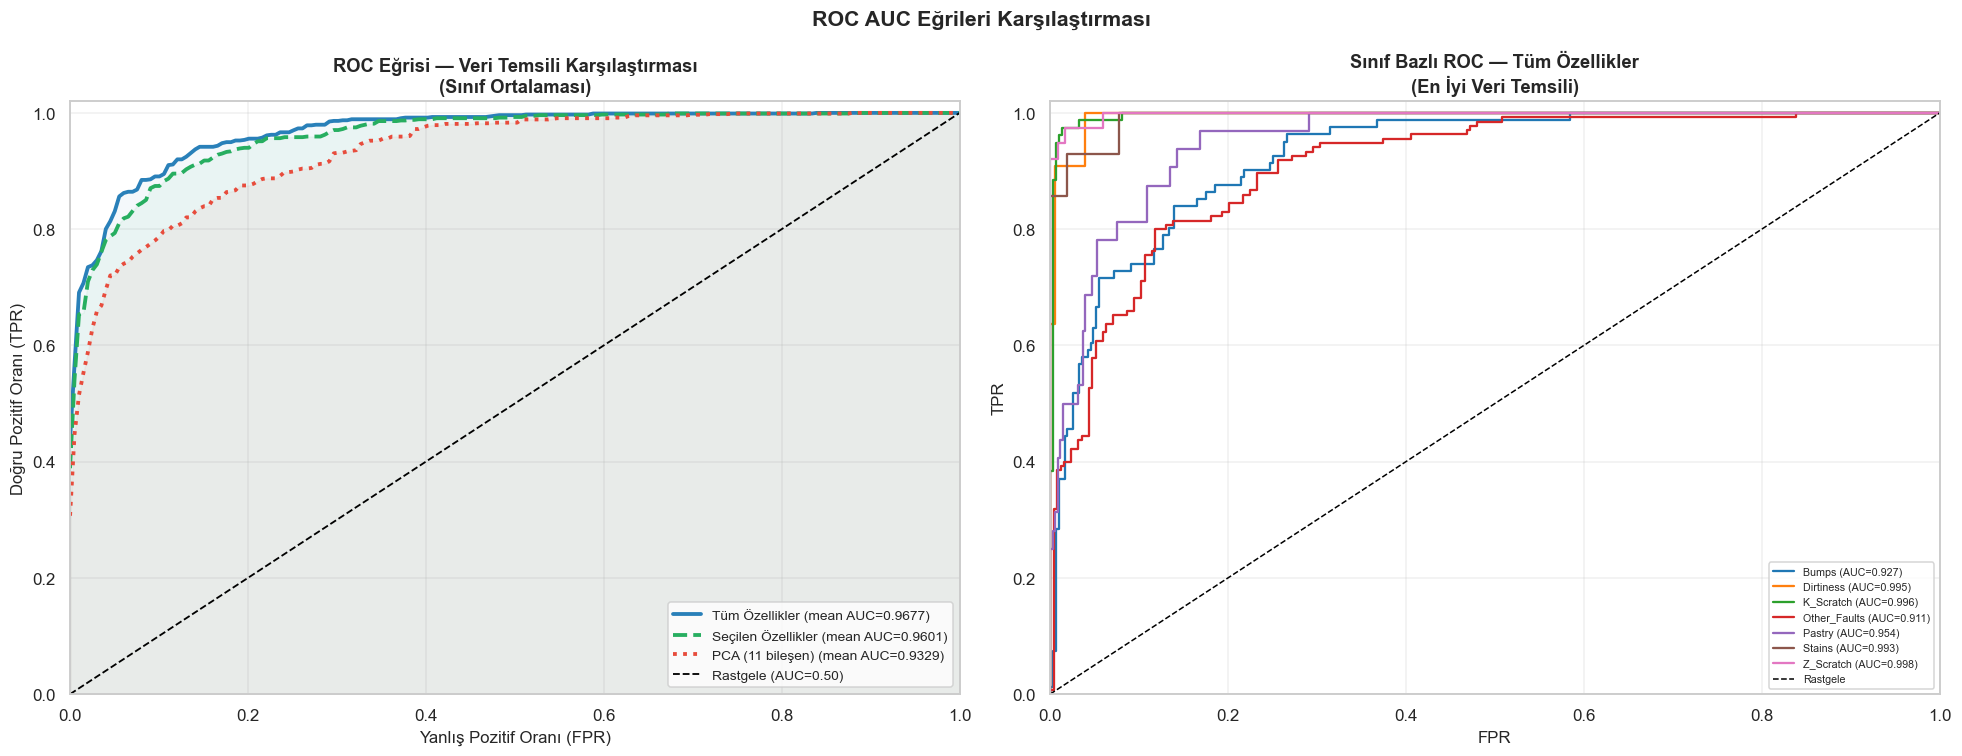

📌 Sol grafik: hangi veri temsili daha iyi ayırt ediyor.
📌 Sağ grafik: en iyi temsilin sınıf bazında güçlü/zayıf yönleri.


In [36]:
ds_colors = ['#2980b9', '#27ae60', '#e74c3c']
line_styles = ['-', '--', ':']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Sol: Her veri temsili için micro-average ROC
for (ds_name, (y_pred_ds, y_prob_ds)), color, ls in zip(
    final_comparisons.items(), ds_colors, line_styles
):
    # OvR micro-average
    fpr_grid  = np.linspace(0, 1, 200)
    tprs      = []
    aucs_list = []
    for i in range(n_classes):
        fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_prob_ds[:, i])
        tprs.append(np.interp(fpr_grid, fpr_i, tpr_i))
        aucs_list.append(auc(fpr_i, tpr_i))
    mean_tpr = np.mean(tprs, axis=0)
    mean_auc = np.mean(aucs_list)

    axes[0].plot(fpr_grid, mean_tpr, color=color, lw=2.5, linestyle=ls,
                 label=f'{ds_name} (mean AUC={mean_auc:.4f})')
    axes[0].fill_between(fpr_grid, mean_tpr, alpha=0.05, color=color)

axes[0].plot([0, 1], [0, 1], 'k--', lw=1.2, label='Rastgele (AUC=0.50)')
axes[0].set_xlabel('Yanlış Pozitif Oranı (FPR)', fontsize=11)
axes[0].set_ylabel('Doğru Pozitif Oranı (TPR)', fontsize=11)
axes[0].set_title('ROC Eğrisi — Veri Temsili Karşılaştırması\n(Sınıf Ortalaması)', fontweight='bold')
axes[0].legend(fontsize=9, loc='lower right')
axes[0].grid(alpha=0.3); axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1.02])

# Sağ: En iyi model için sınıf bazlı ROC
best_ds       = sorted(repr_results, key=lambda r: r['Test F1 (W)'], reverse=True)[0]['Veri Temsili']
best_prob     = repr_probs[best_ds]
roc_colors_cls = sns.color_palette('tab10', n_classes)

for i, cls in enumerate(class_names):
    fpr_c, tpr_c, _ = roc_curve(y_test_bin[:, i], best_prob[:, i])
    auc_c            = auc(fpr_c, tpr_c)
    axes[1].plot(fpr_c, tpr_c, lw=1.5, color=roc_colors_cls[i],
                 label=f'{cls} (AUC={auc_c:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Rastgele')
axes[1].set_xlabel('FPR', fontsize=11); axes[1].set_ylabel('TPR', fontsize=11)
axes[1].set_title(f'Sınıf Bazlı ROC — {best_ds}\n(En İyi Veri Temsili)', fontweight='bold')
axes[1].legend(fontsize=7, loc='lower right')
axes[1].grid(alpha=0.3)
axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.02])

plt.suptitle('ROC AUC Eğrileri Karşılaştırması', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print('📌 Sol grafik: hangi veri temsili daha iyi ayırt ediyor.'
      '\n📌 Sağ grafik: en iyi temsilin sınıf bazında güçlü/zayıf yönleri.')

### 8.3 Precision-Recall Eğrileri Karşılaştırması

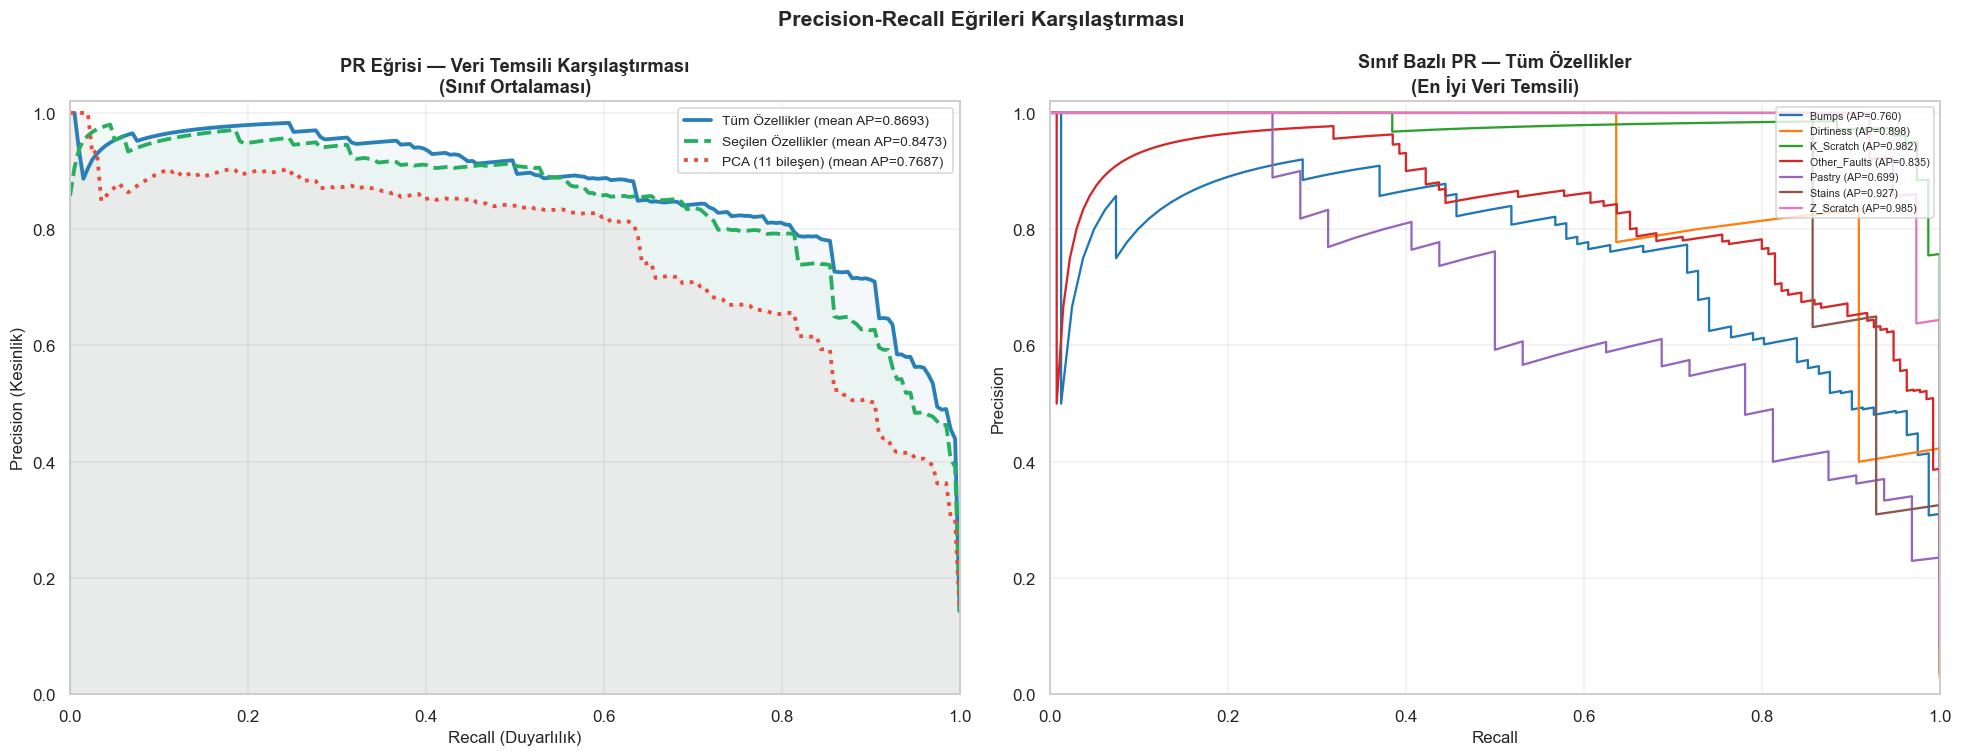

📌 PR eğrisi sınıf dengesizliğinde ROC'tan daha bilgilendiricidir.


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Sol: Veri temsilleri arasında ortalama PR
for (ds_name, (y_pred_ds, y_prob_ds)), color, ls in zip(
    final_comparisons.items(), ds_colors, line_styles
):
    rec_grid = np.linspace(0, 1, 200)
    precs    = []
    aps_list = []
    for i in range(n_classes):
        prec_i, rec_i, _ = precision_recall_curve(y_test_bin[:, i], y_prob_ds[:, i])
        precs.append(np.interp(rec_grid[::-1], rec_i[::-1], prec_i[::-1])[::-1])
        aps_list.append(average_precision_score(y_test_bin[:, i], y_prob_ds[:, i]))
    mean_prec = np.mean(precs, axis=0)
    mean_ap   = np.mean(aps_list)

    axes[0].plot(rec_grid, mean_prec, color=color, lw=2.5, linestyle=ls,
                 label=f'{ds_name} (mean AP={mean_ap:.4f})')
    axes[0].fill_between(rec_grid, mean_prec, alpha=0.05, color=color)

axes[0].set_xlabel('Recall (Duyarlılık)', fontsize=11)
axes[0].set_ylabel('Precision (Kesinlik)', fontsize=11)
axes[0].set_title('PR Eğrisi — Veri Temsili Karşılaştırması\n(Sınıf Ortalaması)', fontweight='bold')
axes[0].legend(fontsize=9, loc='upper right')
axes[0].grid(alpha=0.3); axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1.02])

# Sağ: En iyi model için sınıf bazlı PR
for i, cls in enumerate(class_names):
    prec_c, rec_c, _ = precision_recall_curve(y_test_bin[:, i], best_prob[:, i])
    ap_c = average_precision_score(y_test_bin[:, i], best_prob[:, i])
    axes[1].plot(rec_c, prec_c, lw=1.5, color=roc_colors_cls[i],
                 label=f'{cls} (AP={ap_c:.3f})')

axes[1].set_xlabel('Recall', fontsize=11); axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title(f'Sınıf Bazlı PR — {best_ds}\n(En İyi Veri Temsili)', fontweight='bold')
axes[1].legend(fontsize=7, loc='upper right')
axes[1].grid(alpha=0.3)
axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.02])

plt.suptitle('Precision-Recall Eğrileri Karşılaştırması', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print('📌 PR eğrisi sınıf dengesizliğinde ROC\'tan daha bilgilendiricidir.')

### 8.4 Final Özet Karşılaştırma Tablosu


FINAL KARŞILAŞTIRMA: TÜM ÖZELLİKLER / SEÇİLEN ÖZELLİKLER / PCA (LightGBM — En İyi Model)
      Veri Temsili  Boyut  Test Accuracy  Test F1 (Mac)  Test F1 (W)  Test Precision  Test Recall  AUC-ROC  CV F1 Mac Ort.  CV F1 Mac Std
    Tüm Özellikler     27         0.8201         0.8291       0.8214          0.8264       0.8334   0.9487          0.8094         0.0133
Seçilen Özellikler     15         0.7661         0.7840       0.7685          0.7814       0.7909   0.9368          0.8046         0.0196
  PCA (11 bileşen)     11         0.7147         0.7149       0.7165          0.7410       0.6934   0.9048          0.7194         0.0165


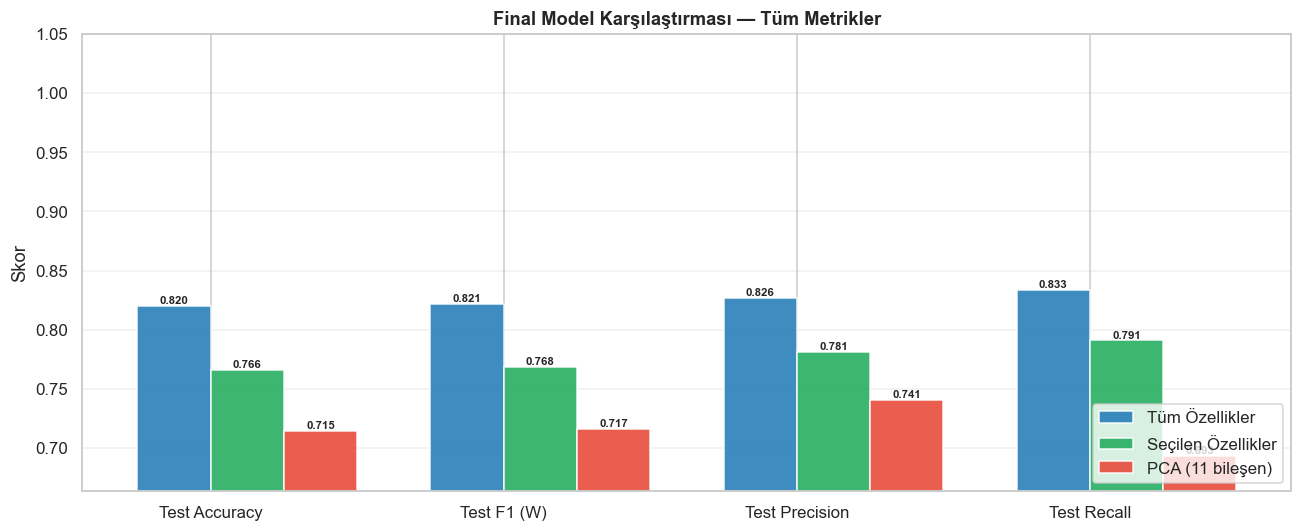

In [38]:
print('\n' + '='*100)
print('FINAL KARŞILAŞTIRMA: TÜM ÖZELLİKLER / SEÇİLEN ÖZELLİKLER / PCA (LightGBM — En İyi Model)')
print('='*100)
print(repr_df.to_string(index=False))
print('='*100)

# Görsel: Radar / Çubuk özet
fig, ax = plt.subplots(figsize=(12, 5))
metrics_bar = ['Test Accuracy', 'Test F1 (W)', 'Test Precision', 'Test Recall']
x_bar       = np.arange(len(metrics_bar))
bar_w       = 0.25

# ÇÖZÜM: itertuples() yerine iterrows() kullanıyoruz.
# Böylece replace() karmaşasına ve _2 gibi hatalara gerek kalmıyor.
for i, ((index, row), color) in enumerate(zip(repr_df.iterrows(), ds_colors)):

    # İlgili metrik değerlerini satırdan doğrudan sütun ismiyle çekiyoruz
    vals = [row[col] for col in metrics_bar]

    # Label ismini yine doğrudan 'Veri Temsili' sütunundan alıyoruz
    bars = ax.bar(x_bar + i * bar_w - bar_w, vals, bar_w,
                  label=row['Veri Temsili'], color=color, edgecolor='white', alpha=0.9)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', fontsize=7.5, fontweight='bold')

ax.set_xticks(x_bar - bar_w/2)
ax.set_xticklabels(metrics_bar)

# Grafiğin alt sınırını ayarlama
try:
    # Tüm metriklerin minimum değerini bulup biraz altından başlatıyoruz
    min_val = repr_df[metrics_bar].min().min()
    ax.set_ylim(min_val - 0.03, 1.05)
except:
    ax.set_ylim(0.5, 1.05)

ax.set_ylabel('Skor')
ax.set_title('Final Model Karşılaştırması — Tüm Metrikler', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 🔬 Step 9 — SHAP Açıklanabilirlik Analizi

In [39]:
# LightGBM modeli üzerinde SHAP
best_shap_model = repr_models.get('Seçilen Özellikler',
                                   list(repr_models.values())[0])

explainer = shap.TreeExplainer(best_shap_model)

np.random.seed(SEED)
shap_idx    = np.random.choice(len(X_test_sc), size=min(300, len(X_test_sc)), replace=False)
X_shap_samp = X_test_sc[shap_idx]

shap_vals = explainer.shap_values(X_shap_samp)
print(f'SHAP değerleri {len(shap_idx)} test örneği için hesaplandı.')

SHAP değerleri 300 test örneği için hesaplandı.


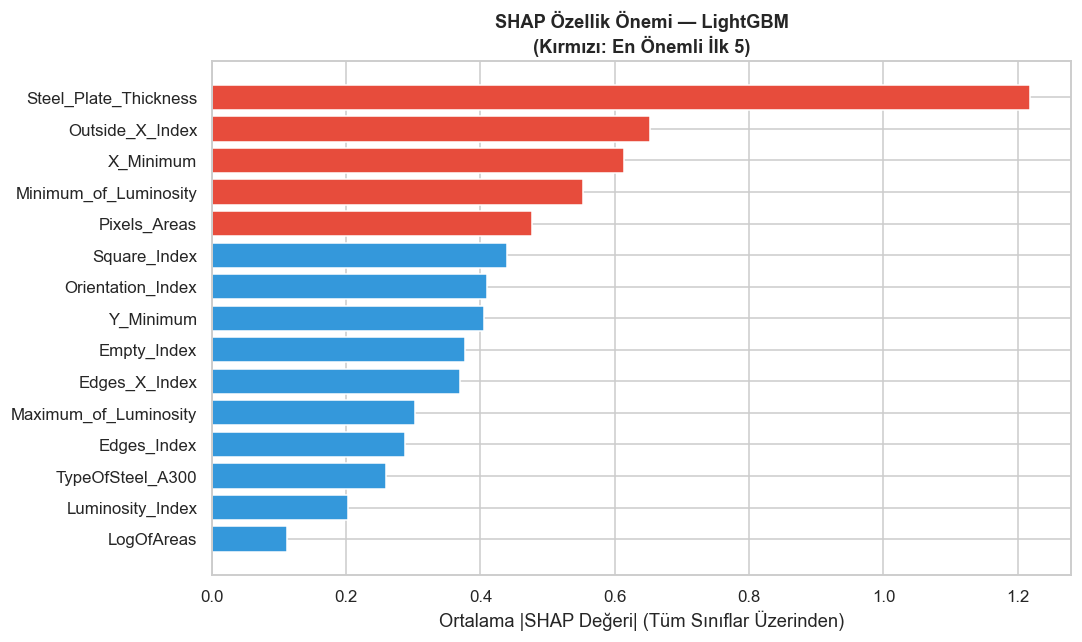

Top-10 SHAP özelliği:
   1. Steel_Plate_Thickness          → 1.21879
   2. Outside_X_Index                → 0.65205
   3. X_Minimum                      → 0.61423
   4. Minimum_of_Luminosity          → 0.55309
   5. Pixels_Areas                   → 0.47702
   6. Square_Index                   → 0.43883
   7. Orientation_Index              → 0.40969
   8. Y_Minimum                      → 0.40571
   9. Empty_Index                    → 0.37684
  10. Edges_X_Index                  → 0.36978


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. SHAP Boyutlarını Güvenli Bir Şekilde Tek Boyuta İndirgeme
if isinstance(shap_vals, list):
    # Eski SHAP Sürümü (Liste Formatı)
    shap_agg = np.mean(np.abs(np.array(shap_vals)), axis=0) # Sınıflar ortalaması
    shap_importance_vals = np.abs(shap_agg).mean(axis=0)    # Örnekler ortalaması
else:
    # Yeni SHAP Sürümü (3 Boyutlu Array: Örnekler x Özellikler x Sınıflar)
    shap_mean = np.abs(shap_vals).mean(axis=0) # Örneklerin ortalamasını al -> (17, 7)
    if len(shap_mean.shape) > 1:
        shap_importance_vals = shap_mean.mean(axis=1) # Sınıfların da ortalamasını al -> (17,)
    else:
        shap_importance_vals = shap_mean

# 2. Pandas Series Oluşturma ve Sıralama
shap_importance = pd.Series(
    shap_importance_vals,
    index=final_features_all
).sort_values(ascending=False)

# 3. Görselleştirme
fig, ax = plt.subplots(figsize=(10, 6))
bars_shap = ax.barh(shap_importance.index[::-1],
                     shap_importance.values[::-1],
                     color=['#e74c3c' if i < 5 else '#3498db'
                            for i in range(len(shap_importance) - 1, -1, -1)],
                     edgecolor='white')

ax.set_xlabel('Ortalama |SHAP Değeri| (Tüm Sınıflar Üzerinden)')
ax.set_title('SHAP Özellik Önemi — LightGBM\n(Kırmızı: En Önemli İlk 5)',
             fontweight='bold')
plt.tight_layout(); plt.show()

# 4. Top-10 Çıktısı
print('Top-10 SHAP özelliği:')
for i, (feat, val) in enumerate(shap_importance.head(10).items(), 1):
    print(f'  {i:2}. {feat:<30} → {val:.5f}')

<Figure size 1100x770 with 0 Axes>

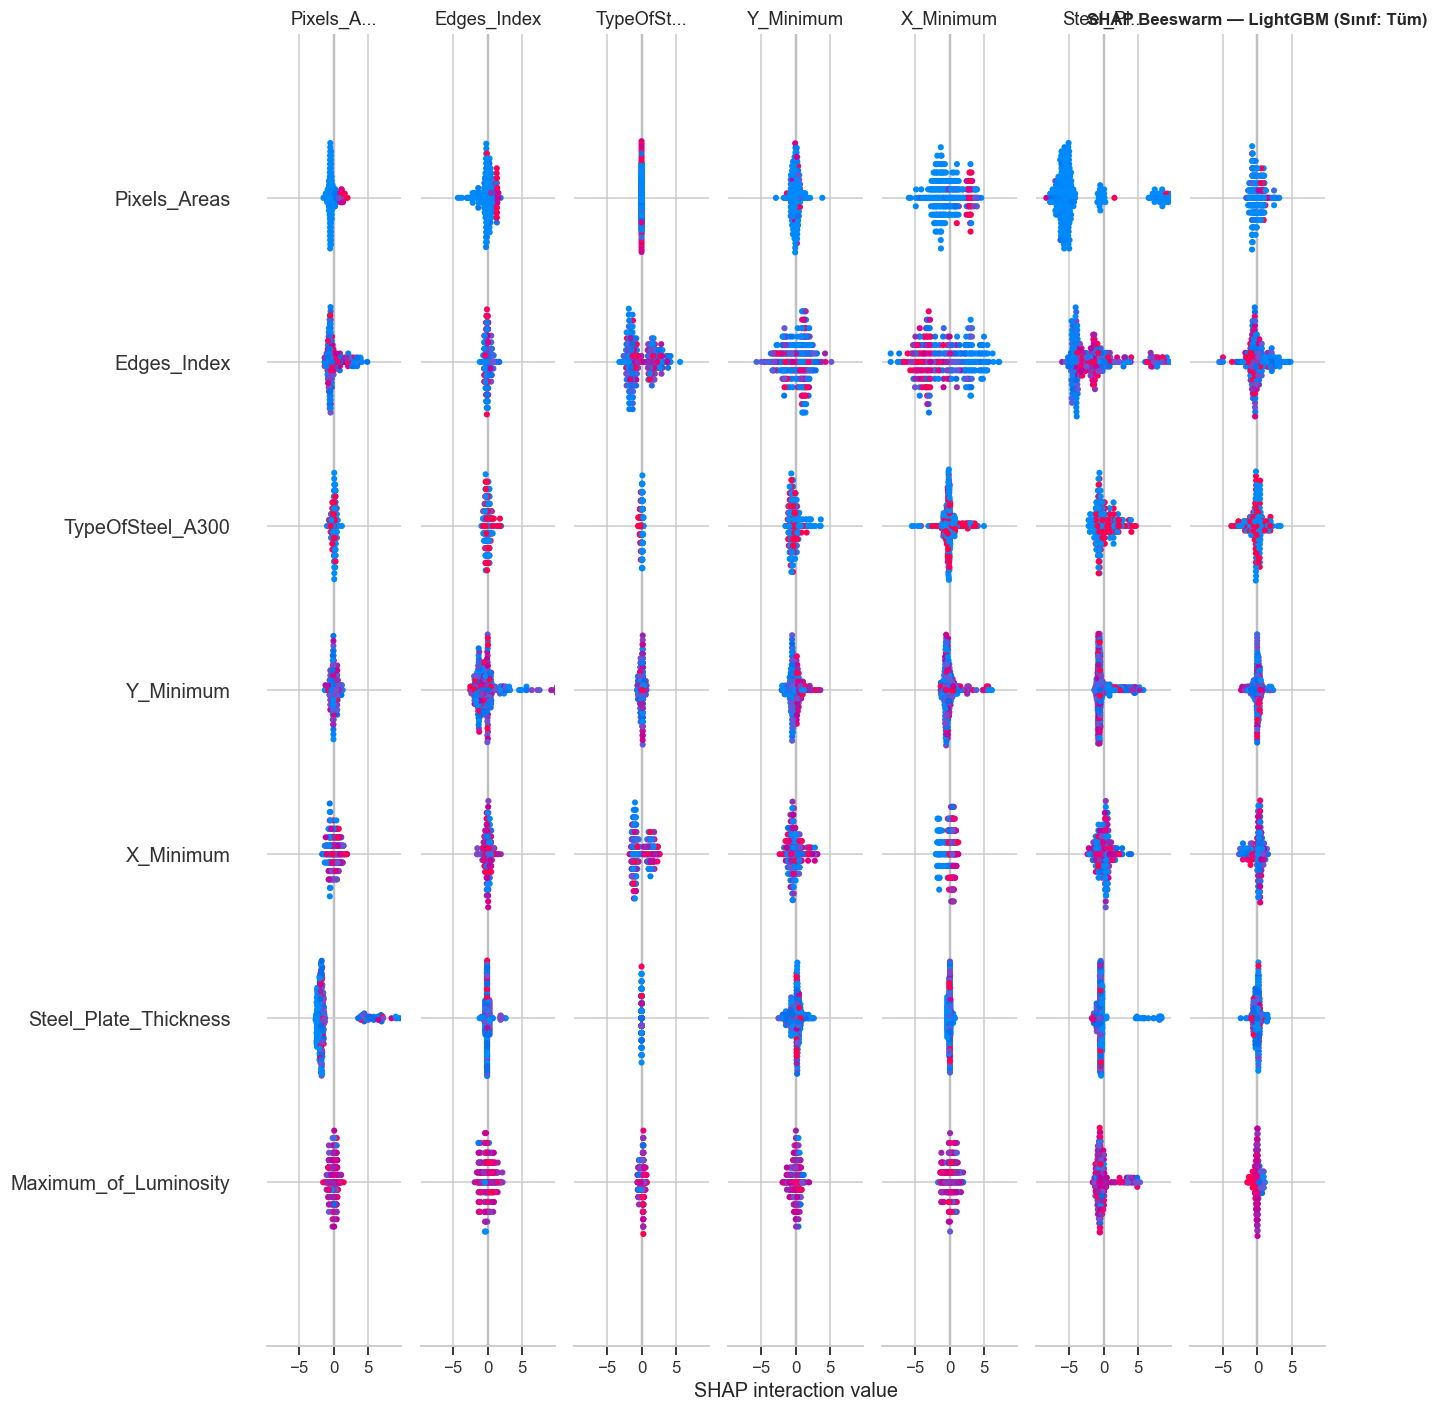

📌 Noktaların rengi özellik değerini (kırmızı=yüksek, mavi=düşük), yatay konum SHAP değerinin büyüklük ve yönünü gösterir.


In [41]:
# SHAP Beeswarm (Birinci sınıf için)
if isinstance(shap_vals, list):
    shap_beeswarm = shap_vals[0]
    cls_label     = class_names[0]
else:
    shap_beeswarm = shap_vals
    cls_label     = 'Tüm'

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_beeswarm,
    pd.DataFrame(X_shap_samp, columns=final_features_all),
    plot_type='dot', show=False, max_display=15
)
plt.title(f'SHAP Beeswarm — LightGBM (Sınıf: {cls_label})',
          fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()
print('📌 Noktaların rengi özellik değerini (kırmızı=yüksek, mavi=düşük),'
      ' yatay konum SHAP değerinin büyüklük ve yönünü gösterir.')

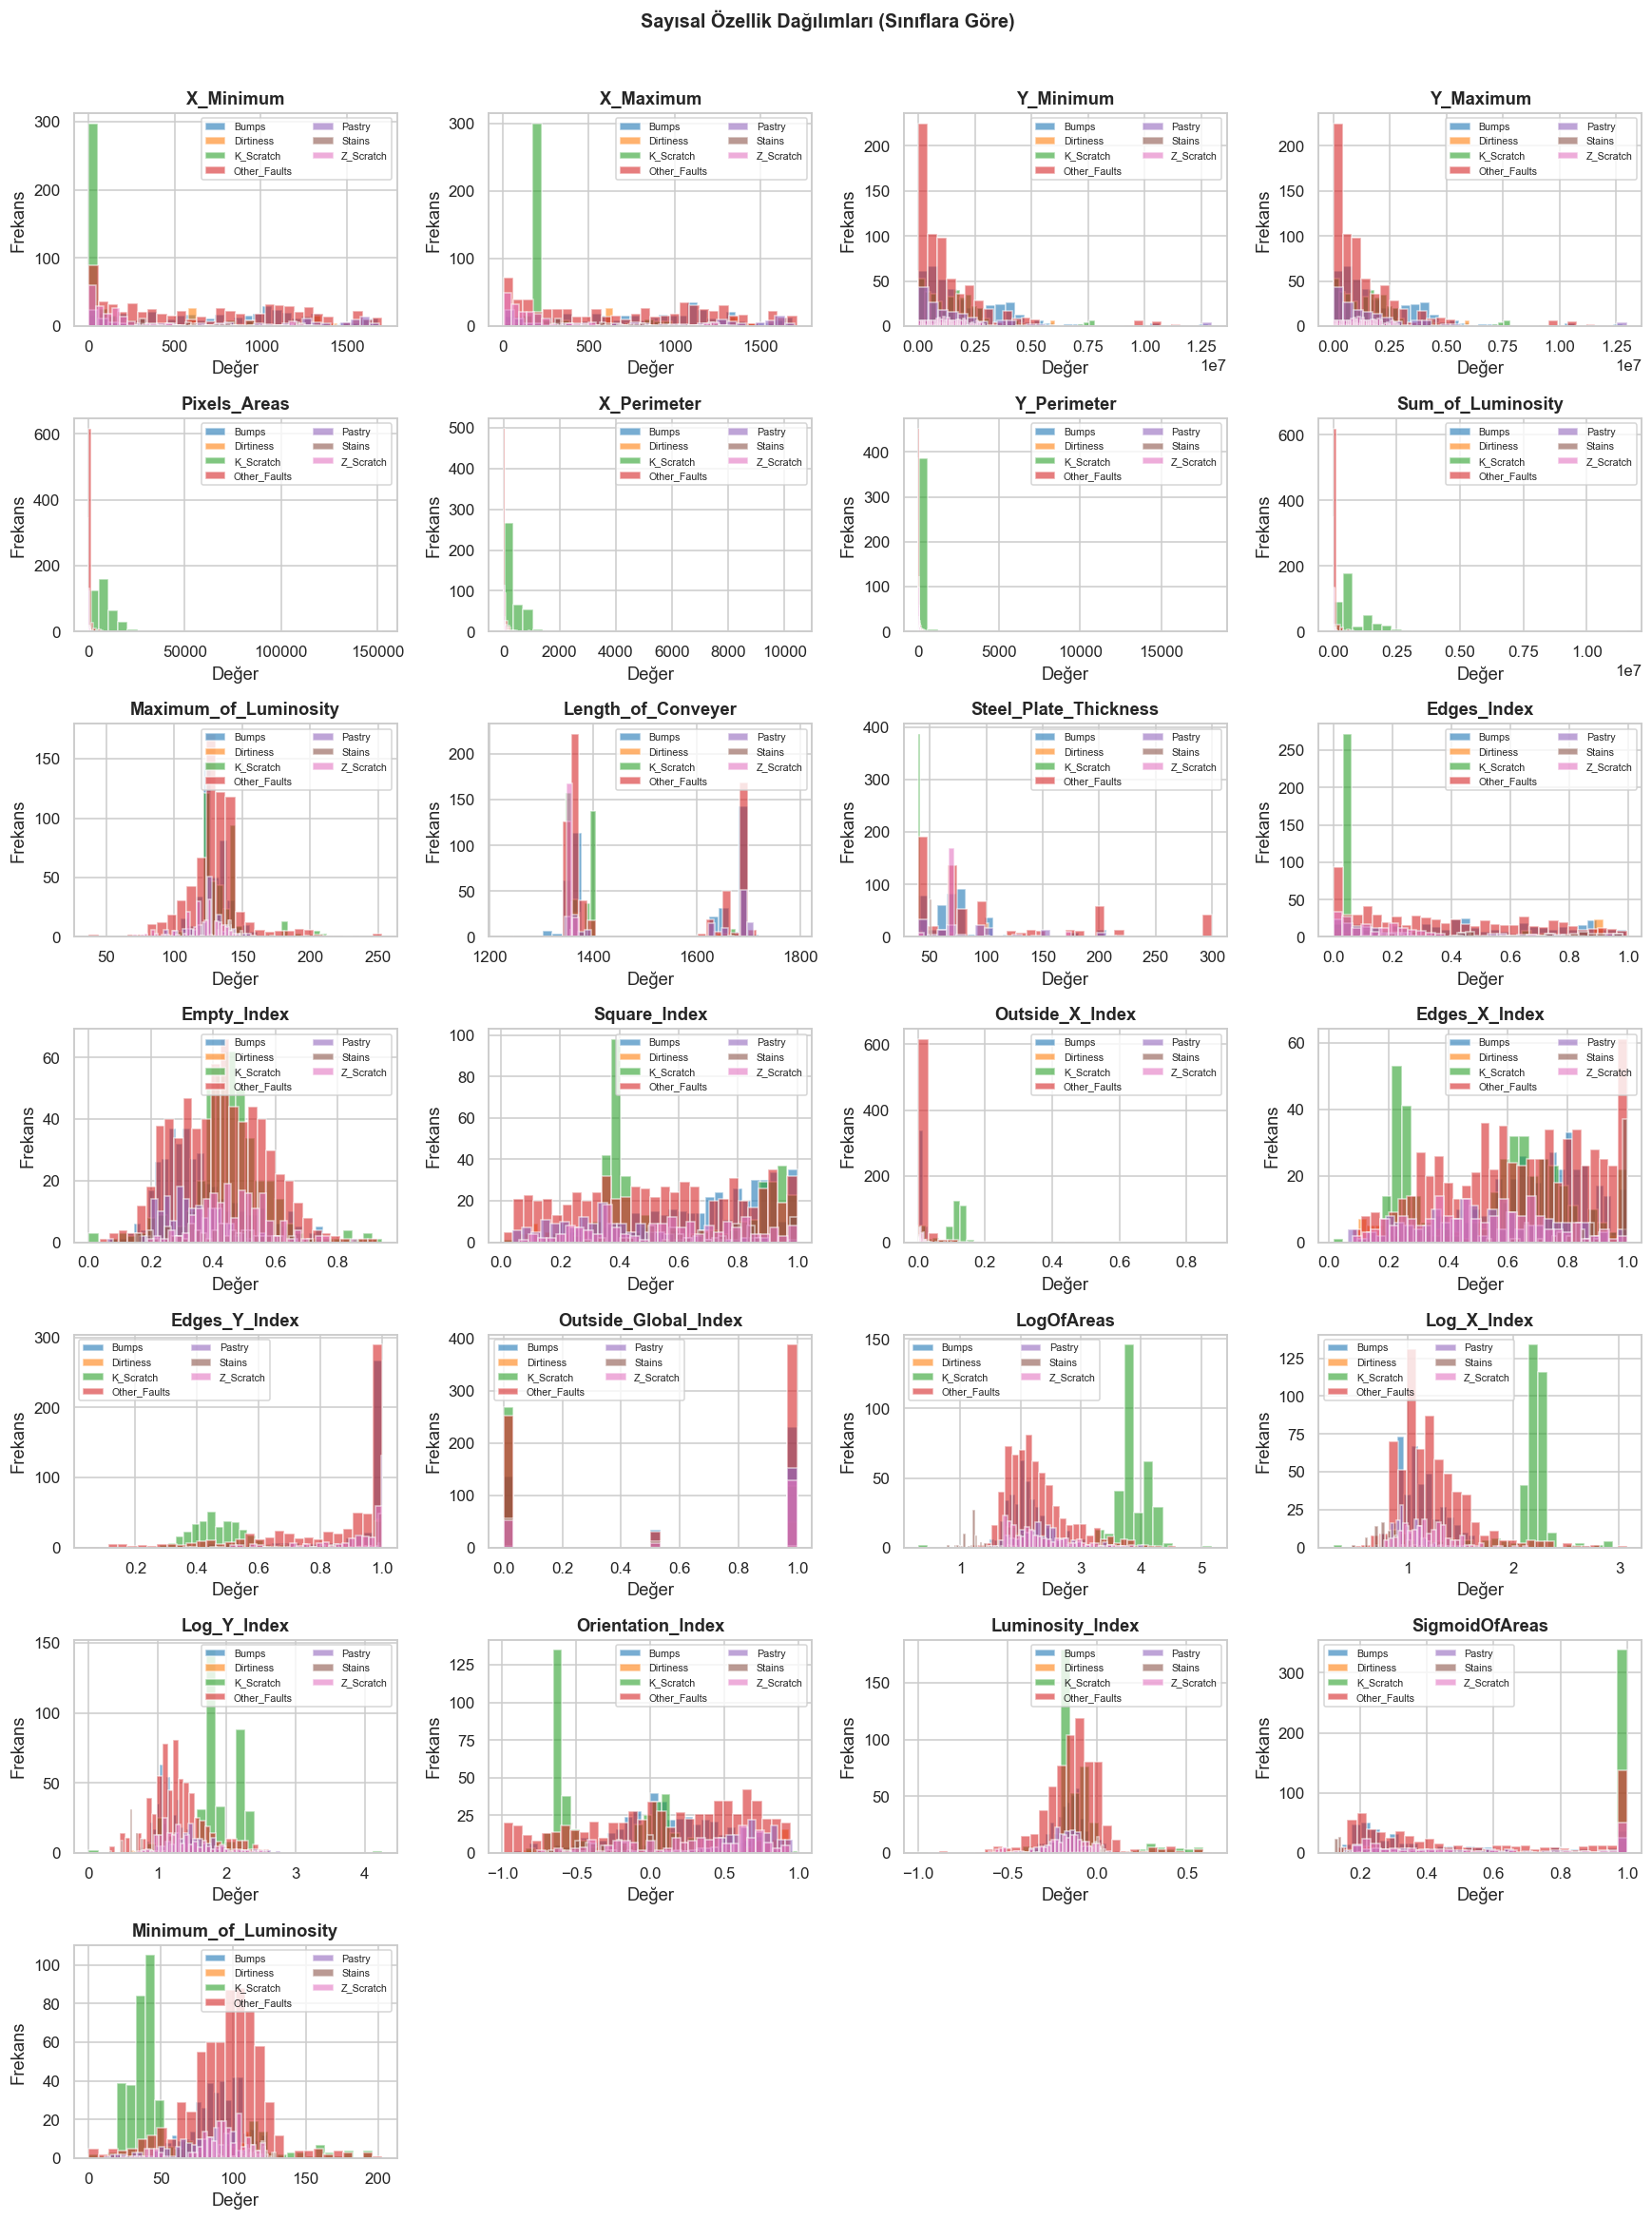

📌 Çarpık dağılım gösteren özellikler PowerTransformer adayıdır.


In [42]:




































































































































# ── Sayısal özelliklerin dağılım grafikleri ─────────────────────────
n_num  = len(num_cols)
ncols  = 4
nrows  = (n_num + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for j, cls in enumerate(class_names):
        mask   = y_enc == j
        subset = X[col][mask]
        axes[i].hist(subset, bins=30, alpha=0.6,
                     color=palette[j], label=cls, edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Değer')
    axes[i].set_ylabel('Frekans')
    axes[i].legend(fontsize=7, ncol=2)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Sayısal Özellik Dağılımları (Sınıflara Göre)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('📌 Çarpık dağılım gösteren özellikler PowerTransformer adayıdır.')

## ✅ Pipeline Özeti

| Adım | İşlem                                                 | Sonuç |
|------|-------------------------------------------------------|-------|
| **EDA** | KNNImputer · LOF · Sınıf dağılımı · Korelasyon cossim | Temiz veri; aykırılar korundu |
| **Özellik Seçimi** | ANOVA + RF Önemi + RFE → Oylama tablosu               | 3 yöntem karşılaştırıldı; en önemli özellikler ilan edildi |
| **Tüm / Seçilen / PCA** | 3 veri temsili ile LightGBM eğitimi                   | Karşılaştırmalı tablo + görsel |
| **Hiperparametre** | optuna                               | 4 model optimize edildi |
| **Değerlendirme** | Acc · F1 · Prec · Rec · AUC-ROC                       | En iyi model belirlendi |
| **Final Görsel** | Confusion Matrix + ROC + PR karşılaştırması           | 3 veri temsili yan yana |
| **SHAP** | TreeExplainer · Beeswarm · Bar                        | En önemli hata sürücüleri: geometri + luminozite |

> **Not:** Bu notebook tamamen yeniden çalıştırılabilir. `SEED=42` ile tüm sonuçlar tekrarlanabilir.
